# Exploration

In [2]:

#datasets = ["seen_d1","seen_d2", "seen_d3", "seen_d4", "unseen_d1", "unseen_d2", "unseen_d3", "unseen_d4", "seen_d1_strat", "seen_d2_strat", "seen_d3_strat", "seen_d4_strat", "unseen_d1_strat", "unseen_d2_strat", "unseen_d3_strat", "unseen_d4_strat"]
#datasets = ["seen_d1","seen_d2", "seen_d3", "seen_d4", "unseen_d1", "unseen_d2", "unseen_d3", "unseen_d4", "seen_d1_strat", "seen_d2_strat", "seen_d3_strat", "seen_d4_strat", "unseen_d1_strat", "unseen_d2_strat", "unseen_d3_strat", "unseen_d4_strat"]
#datasets = ["unseen_d1", "unseen_d1_strat", "unseen_d2", "unseen_d2_strat", "unseen_d3", "unseen_d3_strat", "unseen_d4", "unseen_d4_strat"]
#datasets = ["seen_d4_lower_sensor", "seen_d4_higher_sensor", "seen_d1_lower_sensor", "seen_d1_higher_sensor", "seen_d4_low", "seen_d4_high", "seen_d1_low", "seen_d1_high"]
datasets = ["seen_d1"]
folds = [i for i in range(10)]
models = ["top10nn"]

d_array = []
f_array = []
m_array = []
for fold in folds:
    for model in models:
        for dataset in datasets:
            d_array.append(dataset)
            f_array.append(fold)
            m_array.append(model)

d_st = "("
for i in d_array:
    d_st += f"\"{i}\" "
d_st = d_st[:-1] + ")"

f_st = "("
for i in f_array:
    f_st += f"\"{i}\" "
f_st = f_st[:-1] + ")"

m_st = "("
for i in m_array:
    m_st += f"\"{i}\" "
m_st = m_st[:-1] + ")"

m_st = "("
for i in m_array:
    m_st += f"\"{i}\" "
m_st = m_st[:-1] + ")"

print(d_st)
print(f_st)
print(m_st)
# print(m_st)
print(len(d_array))


("seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1" "seen_d1")
("0" "1" "2" "3" "4" "5" "6" "7" "8" "9")
("top10nn" "top10nn" "top10nn" "top10nn" "top10nn" "top10nn" "top10nn" "top10nn" "top10nn" "top10nn")
10


In [3]:
learning_rate = []
for i in range(1, 10):  
    for j in range(2, 7):  
        lr = i * 10**(-j)
        learning_rate.append(lr)

print(learning_rate)

[0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.02, 0.002, 0.0002, 2e-05, 2e-06, 0.03, 0.003, 0.00030000000000000003, 3.0000000000000004e-05, 3e-06, 0.04, 0.004, 0.0004, 4e-05, 4e-06, 0.05, 0.005, 0.0005, 5e-05, 4.9999999999999996e-06, 0.06, 0.006, 0.0006000000000000001, 6.000000000000001e-05, 6e-06, 0.07, 0.007, 0.0007, 7.000000000000001e-05, 7e-06, 0.08, 0.008, 0.0008, 8e-05, 8e-06, 0.09, 0.009000000000000001, 0.0009000000000000001, 9e-05, 9e-06]


In [4]:
from dataset.k_fold_shore_data_module import KFoldShoreDataModule


data_dir = "/home/malte.kuhlmann/youngs-modulus/data"
folder_name = "hardness_ds"

data_module = KFoldShoreDataModule(data_dir, folder_name, seen=False, batch_size=1)
data_module.prepare_data()

data_module.setup(fold=3)
for batch in data_module.test_dataloader():
    print(batch)
    break

{'min_modulus': 1000.0, 'max_modulus': 10000000.0, 'min_estimate': 100.0, 'max_estimate': 10000000.0, 'max_depth': 7.0, 'max_width': 0.08, 'max_force': 60.0}
Using log normalization
Start generating data
Already Exists
Generated all data
Start generating folds
Already Exists
Generated all folds


KeyboardInterrupt: 

In [ ]:
for batch in data_module.test_dataloader():
    x_frames, x_forces, x_widths, x_estimations, y, _ = batch
    print(x_frames.shape)
    break

torch.Size([1, 3, 3, 250, 350])


In [ ]:
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule
from hydra import compose, initialize
from omegaconf import OmegaConf

with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="train",)
    cfg = OmegaConf.to_container(cfg, resolve=True)
    model_config = cfg["dataset"]
    model_config["random_state"] = cfg["settings"]["random_state"]
    

data_module = KFoldYoungsDataModule(
    data_dir=model_config['data_dir'],
    training_data_folder=model_config['training_data_folder'],
    worker=10,
    image_style=model_config['img_style'],
    sample_type=model_config['sample_type'],
    use_estimations=model_config['use_estimations'],
    use_force=model_config['use_force'],
    use_width=model_config['use_width'],
    use_width_transforms=model_config['use_width_transforms'],
    use_markers=model_config['use_markers'],
    remove_paper=model_config['remove_paper'],
    overwrite_file=False,
    batch_size=1,
    val_on_seen_objects=model_config["val_on_seen_objects"],
    use_log_normalization=model_config["use_log_normalization"],
    # stratify_with_magnitude=model_config["stratify_with_magnitude"],
    exclude=model_config['exclude'],
    n_splits=model_config['n_splits'],
    use_cross_validation=model_config['use_cross_validation'],
    compliance=model_config['compliance'],
    same_test_set=model_config['same_test_set'],
    # exclude_shape=model_config['exclude_shape'],
    random_state=model_config['random_state'],
    balance_dataset=model_config["balance_dataset"],
    balance_position=model_config["balance_position"],
    balance_bucket=model_config["balance_bucket"],
    balance_threshold=model_config["balance_threshold"],
    balance_test_set=model_config["balance_test_set"],
    full_dataset_undersample=model_config["full_dataset_undersample"],
    full_dataset_undersample_amount=model_config["full_dataset_undersample_amount"],
)

print(data_module.get_dataset_name())
data_module.prepare_data()

data_module.setup(fold=0)
for batch in data_module.test_dataloader():
    print(batch)
    break

/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/dataset_random_seen_both_log_normalize_removed_paper_balanced_50_no_cross_validation_random_state_0_random_dataset.pkl
Using log normalization
dataset_random_seen_both_log_normalize_removed_paper_balanced_50_no_cross_validation_random_state_0_random_dataset.pkl
Dataset already exists
Loading data
Train: 5057
Val: 1333
Test: 975
[tensor([[[[[0.4961, 0.4961, 0.5000,  ..., 0.4961, 0.4922, 0.4922],
           [0.4922, 0.4961, 0.4961,  ..., 0.4961, 0.4922, 0.4922],
           [0.4961, 0.4961, 0.5000,  ..., 0.4961, 0.4922, 0.4922],
           ...,
           [0.5000, 0.5000, 0.4961,  ..., 0.4961, 0.4961, 0.4961],
           [0.5000, 0.5039, 0.5039,  ..., 0.4961, 0.4961, 0.4961],
           [0.5000, 0.5039, 0.5039,  ..., 0.4961, 0.4961, 0.4961]],

          [[0.5000, 0.4961, 0.4961,  ..., 0.4922, 0.5000, 0.5000],
           [0.5039, 0.4961, 0.4961,  ..., 0.4922, 0.5000, 0.5000],
           [0.5039, 0.4961, 0.5000,  ..., 0.4922, 0.50

  0%|          | 0/3117 [00:00<?, ?it/s]

100%|██████████| 975/975 [00:05<00:00, 176.01it/s]


Counter({'Irregular_Plastic': 43, 'Irregular_Metal': 40, 'Irregular_Rubber': 26, 'Cylinder_Metal': 18, 'Cylinder_Plastic': 13, 'Rectangular_Foam': 12, 'Cylinder_Rubber': 10, 'Sphere_Rubber': 9, 'Cylinder_Wood': 8, 'Rectangular_Rubber': 8, 'Rectangular_Metal': 8, 'Rectangular_Wood': 7, 'Sphere_Plastic': 7, 'Irregular_Wood': 6, 'Rectangular_Plastic': 5, 'Hex_Metal': 4, 'Sphere_Glass': 3, 'Irregular_Food': 3, 'Cylinder_Glass': 3, 'Sphere_Metal': 2, 'Cylinder_Foam': 2, 'Irregular_Glass': 2, 'Cylinder_Ceramic': 2, 'Sphere_Foam': 1, 'Irregular_Ceramic': 1, 'Hex_Plastic': 1, 'Irregular_Foam': 1, 'Sphere_Wood': 1, 'Cylinder_Food': 1, 'Hex_Wood': 1, 'Sphere_Ceramic': 1})
['Irregular_Wood', 'Rectangular_Wood', 'Cylinder_Wood', 'Sphere_Metal', 'Rectangular_Plastic', 'Rectangular_Rubber', 'Sphere_Foam', 'Sphere_Rubber', 'Sphere_Glass', 'Cylinder_Foam', 'Rectangular_Metal', 'Irregular_Ceramic', 'Hex_Plastic', 'Irregular_Glass', 'Irregular_Foam', 'Hex_Metal', 'Sphere_Wood', 'Irregular_Food', 'Sphere

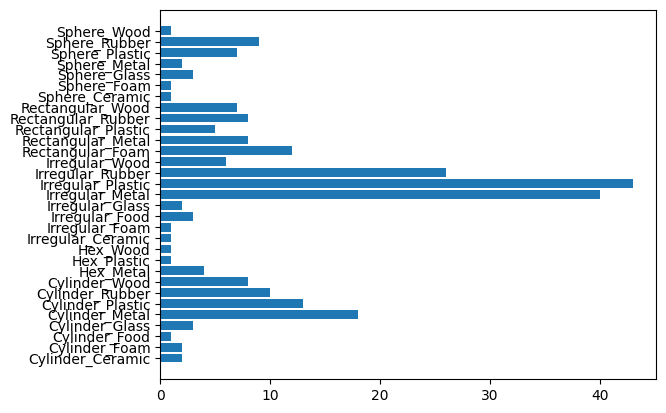

In [ ]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import tqdm
data_module.make_object_attributes()
all_object_names = []
all_y = []
for loader in [data_module.train_dataloader(apply_augmentations=False), data_module.val_dataloader(apply_augmentations=False), data_module.test_dataloader(apply_augmentations=False)]:
    for batch in tqdm.tqdm(loader):
        x_frames, force, width, estimation, y, object_name = batch
        
        all_y.append(data_module.unnormalization_function(y[0][0].detach().numpy()))
        all_object_names.append(object_name[0])

all_y = np.array(all_y)
all_y = np.log10(all_y)

tmp_object_names = np.array(all_object_names)
all_object_names = list(set(all_object_names))
all_stratified_classes = []
for object in all_object_names:
    all_stratified_classes.append(f"{data_module.object_to_shape[object]}_{data_module.object_to_material[object]}")

all_counted_classes = Counter(all_stratified_classes)

print(all_counted_classes)
to_small_classes = []
for key in all_counted_classes.keys():
    if all_counted_classes[key] < 10:
        to_small_classes.append(key)
print(to_small_classes)
print(len(all_object_names))

all_values = []
all_names = sorted(all_counted_classes.keys())
for name in all_names:
    all_values.append(all_counted_classes[name])

plt.barh(all_names, all_values)
plt.show()

In [ ]:
import numpy as np
import tqdm
from sklearn.preprocessing import KBinsDiscretizer
bucket_discretizer = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="uniform",
    random_state=42
)
tmp_all_y = []
sub_y = []
mi_ma_l = []
for loader in [data_module.train_dataloader(), data_module.val_dataloader(), data_module.test_dataloader()]:
    tmp_y = []
    for batch in tqdm.tqdm(loader):
        x_frames, force, width, estimation, y, object_name = batch
        # print(y)
        tmp_y.append(y[0][0].detach().numpy())
        tmp_all_y.append(y[0][0].detach().numpy())
        mi_ma_l.append(data_module.unnormalization_function(y[0][0].detach().numpy()))
    print(tmp_y)
    tmp_y = np.array(tmp_y)
    sub_y.append(tmp_y)
    print(tmp_y)

tmp_all_y = np.array(tmp_all_y)

bucket_discretizer.fit(tmp_all_y.reshape(-1, 1))
tmp_bucket_ids = bucket_discretizer.transform(tmp_all_y.reshape(-1, 1)).reshape(-1).astype(np.int64)
tmp_bin_frequency = np.bincount(tmp_bucket_ids)
print(tmp_bin_frequency)

tmp_bucket_ids = bucket_discretizer.transform(sub_y[0].reshape(-1, 1)).reshape(-1).astype(np.int64)
tmp_bin_frequency = np.bincount(tmp_bucket_ids)
print(tmp_bin_frequency)


tmp_bucket_ids = bucket_discretizer.transform(sub_y[1].reshape(-1, 1)).reshape(-1).astype(np.int64)
tmp_bin_frequency = np.bincount(tmp_bucket_ids)
print(tmp_bin_frequency)


tmp_bucket_ids = bucket_discretizer.transform(sub_y[2].reshape(-1, 1)).reshape(-1).astype(np.int64)
tmp_bin_frequency = np.bincount(tmp_bucket_ids)
print(tmp_bin_frequency)

print(np.min(mi_ma_l), np.max(mi_ma_l))


100%|██████████| 6234/6234 [00:30<00:00, 201.98it/s]


[array(0.2745744, dtype=float32), array(0.22780272, dtype=float32), array(0.62537676, dtype=float32), array(0.6799459, dtype=float32), array(0.2745744, dtype=float32), array(0.2745744, dtype=float32), array(0.2745744, dtype=float32), array(0.2745744, dtype=float32), array(0.20440787, dtype=float32), array(0.20440787, dtype=float32), array(0.6799459, dtype=float32), array(0.53182966, dtype=float32), array(0.53182966, dtype=float32), array(0.22780272, dtype=float32), array(0.22780272, dtype=float32), array(0.8202664, dtype=float32), array(0.7734929, dtype=float32), array(0.7734929, dtype=float32), array(0.71892387, dtype=float32), array(0.2745744, dtype=float32), array(0.20440787, dtype=float32), array(0.35252973, dtype=float32), array(0.20440787, dtype=float32), array(0.9138134, dtype=float32), array(0.22780272, dtype=float32), array(0.22780272, dtype=float32), array(0.88263106, dtype=float32), array(0.7111282, dtype=float32), array(0.42269075, dtype=float32), array(0.5630123, dtype=flo

100%|██████████| 1759/1759 [00:15<00:00, 116.87it/s]


[array(0.50064737, dtype=float32), array(0.22780272, dtype=float32), array(0.50064737, dtype=float32), array(0.75010616, dtype=float32), array(0.6799459, dtype=float32), array(0.2745744, dtype=float32), array(0.42269075, dtype=float32), array(0.8202664, dtype=float32), array(0.35252973, dtype=float32), array(0.9138134, dtype=float32), array(0.35252973, dtype=float32), array(0.4538745, dtype=float32), array(0.29016966, dtype=float32), array(0.9138134, dtype=float32), array(0.8202664, dtype=float32), array(0.29016966, dtype=float32), array(0.6799459, dtype=float32), array(0.53182966, dtype=float32), array(0.41489586, dtype=float32), array(0.6799459, dtype=float32), array(0.4538745, dtype=float32), array(0.22780272, dtype=float32), array(0.53182966, dtype=float32), array(0.19661687, dtype=float32), array(0.42269075, dtype=float32), array(0.35252973, dtype=float32), array(0.29016966, dtype=float32), array(0.39150915, dtype=float32), array(0.8202664, dtype=float32), array(0.41489586, dtype=

100%|██████████| 1912/1912 [00:15<00:00, 122.16it/s]


[array(0.7734929, dtype=float32), array(0.53182966, dtype=float32), array(0.20440787, dtype=float32), array(0.71892387, dtype=float32), array(0.53182966, dtype=float32), array(0.6799459, dtype=float32), array(0.39150915, dtype=float32), array(0.695537, dtype=float32), array(0.53182966, dtype=float32), array(0.53182966, dtype=float32), array(0.75010616, dtype=float32), array(0.6487635, dtype=float32), array(0.5786032, dtype=float32), array(0.695537, dtype=float32), array(0.695537, dtype=float32), array(0.23560123, dtype=float32), array(0.88263106, dtype=float32), array(0.2745744, dtype=float32), array(0.2745744, dtype=float32), array(0.20440787, dtype=float32), array(0.8202664, dtype=float32), array(0.695537, dtype=float32), array(0.6487635, dtype=float32), array(0.62537676, dtype=float32), array(0.695537, dtype=float32), array(0.75010616, dtype=float32), array(0.88263106, dtype=float32), array(0.53182966, dtype=float32), array(0.41489586, dtype=float32), array(0.53182966, dtype=float32

In [ ]:
print(np.min(mi_ma_l), np.max(mi_ma_l))

4271.000108901891 4521199.269489598


27
43.17269076305221
2
342


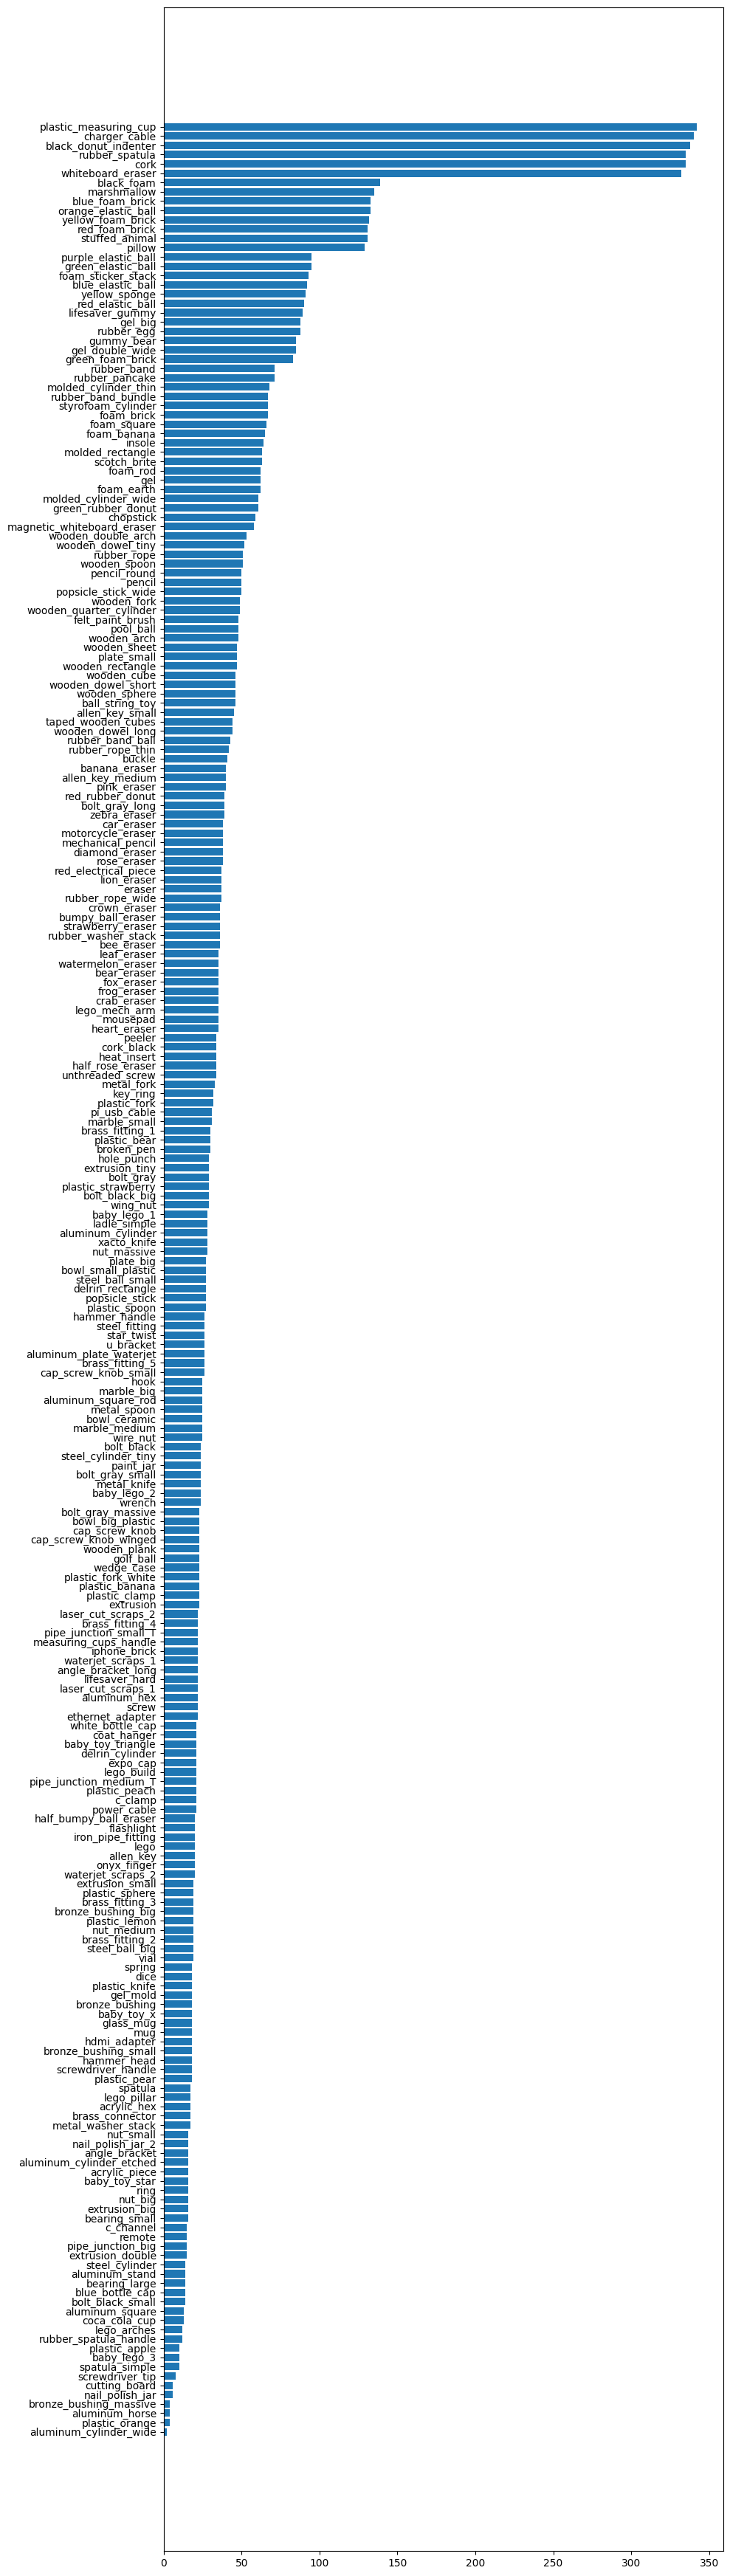

In [ ]:
counter = Counter(tmp_object_names)

names = list(counter.keys())
all_values = []
for name in names:
    all_values.append(counter[name])
all_values = np.array(all_values)
names = np.array(names)
mask = np.argsort(all_values)
names = names[mask]
all_values = all_values[mask]

median = all_values[len(all_values)//2]
print(median)
print(all_values.mean())
print(np.min(all_values))
print(np.max(all_values))
f, ax = plt.subplots(1, 1, figsize=(10, 35))
ax.barh(names, all_values)
f.tight_layout()
f.savefig("../figures/object_datapoint_dist.pdf", dpi=300)
f.show()


[[ 6.5224442]
 [10.       ]
 [ 5.4393325]
 ...
 [11.30103  ]
 [10.       ]
 [ 4.4771214]]


/tmp/ipykernel_793138/3790619990.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'1e{int(x)}' for x in xticks])


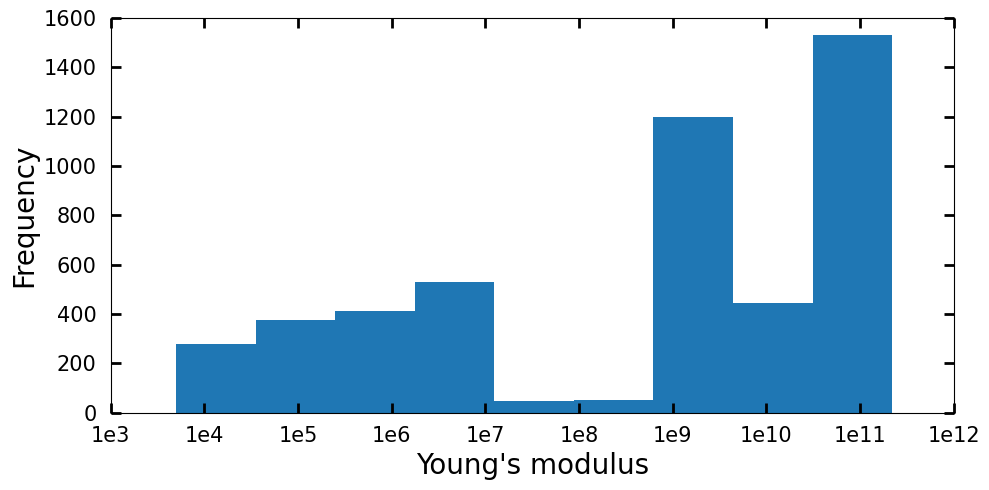

In [ ]:
bins = 9
print(all_y)
f, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(all_y, bins=bins)

ax.set_xlabel("Young's modulus", fontsize=20)
ax.set_ylabel("Frequency", fontsize=20)
ax.tick_params(axis='both', which='major', width=2, length=7, pad=10)
ax.tick_params(axis='both', which='minor', width=1, length=4, pad=5)
# ax.set_title("Distribution of Young's modulus", fontsize=20)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=15)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# Set limits for x and y axis
ax.set_xlim([3, 12])
ax.set_ylim([0, 1600])  # Adjust the y-axis limit as needed

# Prepend text to x labels
xticks = ax.get_xticks()
ax.set_xticklabels([f'1e{int(x)}' for x in xticks])

f.tight_layout()
f.savefig("../figures/y_distribution.pdf", dpi=300)

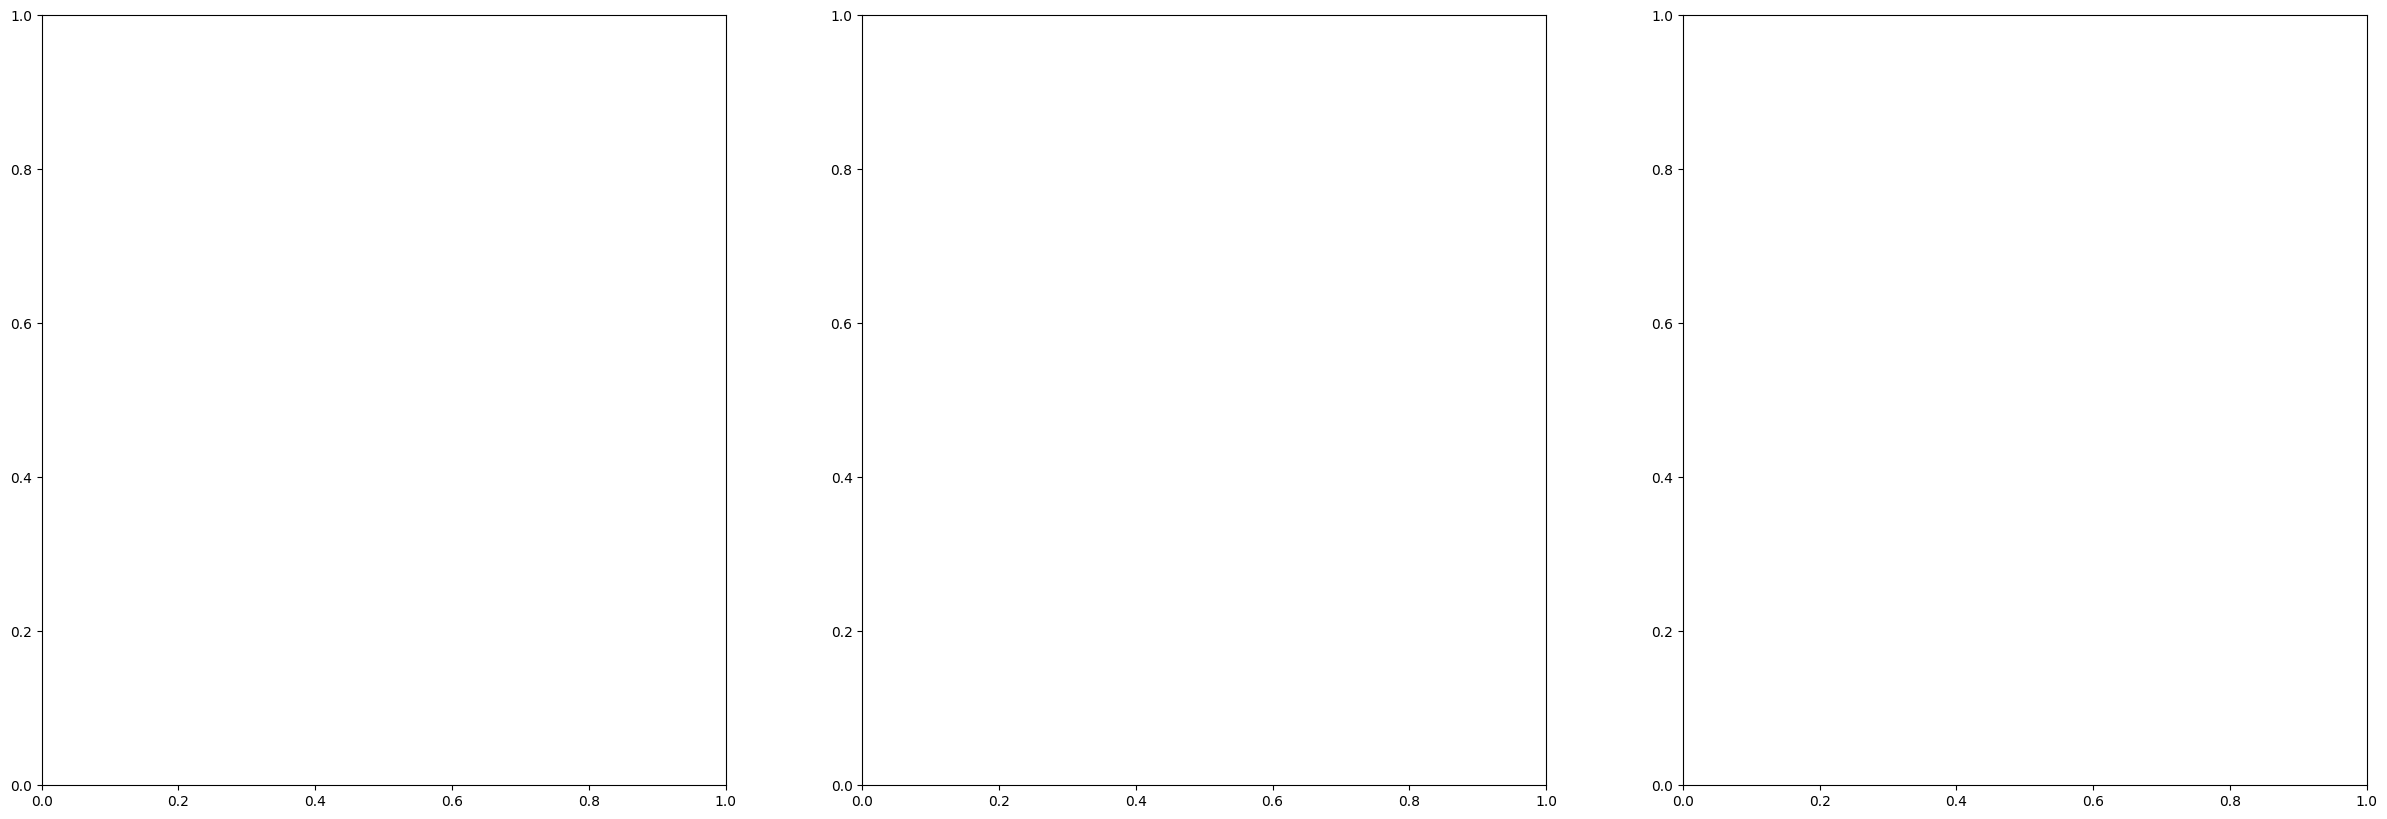

In [ ]:
import matplotlib.pyplot as plt

f, axis = plt.subplots(1,3, figsize=(30,10))

100%|██████████| 975/975 [00:12<00:00, 80.81it/s] 


Counter({'Irregular_Plastic': 43, 'Irregular_Metal': 40, 'Irregular_Rubber': 26, 'Cylinder_Metal': 18, 'Cylinder_Plastic': 13, 'Rectangular_Foam': 12, 'Cylinder_Rubber': 10, 'Sphere_Rubber': 9, 'Rectangular_Rubber': 8, 'Rectangular_Metal': 8, 'Cylinder_Wood': 8, 'Sphere_Plastic': 7, 'Rectangular_Wood': 7, 'Irregular_Wood': 6, 'Rectangular_Plastic': 5, 'Hex_Metal': 4, 'Sphere_Glass': 3, 'Cylinder_Glass': 3, 'Irregular_Food': 3, 'Sphere_Metal': 2, 'Cylinder_Foam': 2, 'Irregular_Glass': 2, 'Cylinder_Ceramic': 2, 'Hex_Plastic': 1, 'Irregular_Ceramic': 1, 'Irregular_Foam': 1, 'Sphere_Ceramic': 1, 'Sphere_Foam': 1, 'Hex_Wood': 1, 'Sphere_Wood': 1, 'Cylinder_Food': 1})
['Rectangular_Rubber', 'Sphere_Rubber', 'Sphere_Glass', 'Rectangular_Metal', 'Irregular_Wood', 'Sphere_Plastic', 'Cylinder_Glass', 'Rectangular_Plastic', 'Sphere_Metal', 'Hex_Plastic', 'Cylinder_Wood', 'Cylinder_Foam', 'Irregular_Ceramic', 'Irregular_Glass', 'Hex_Metal', 'Rectangular_Wood', 'Cylinder_Ceramic', 'Irregular_Foam',

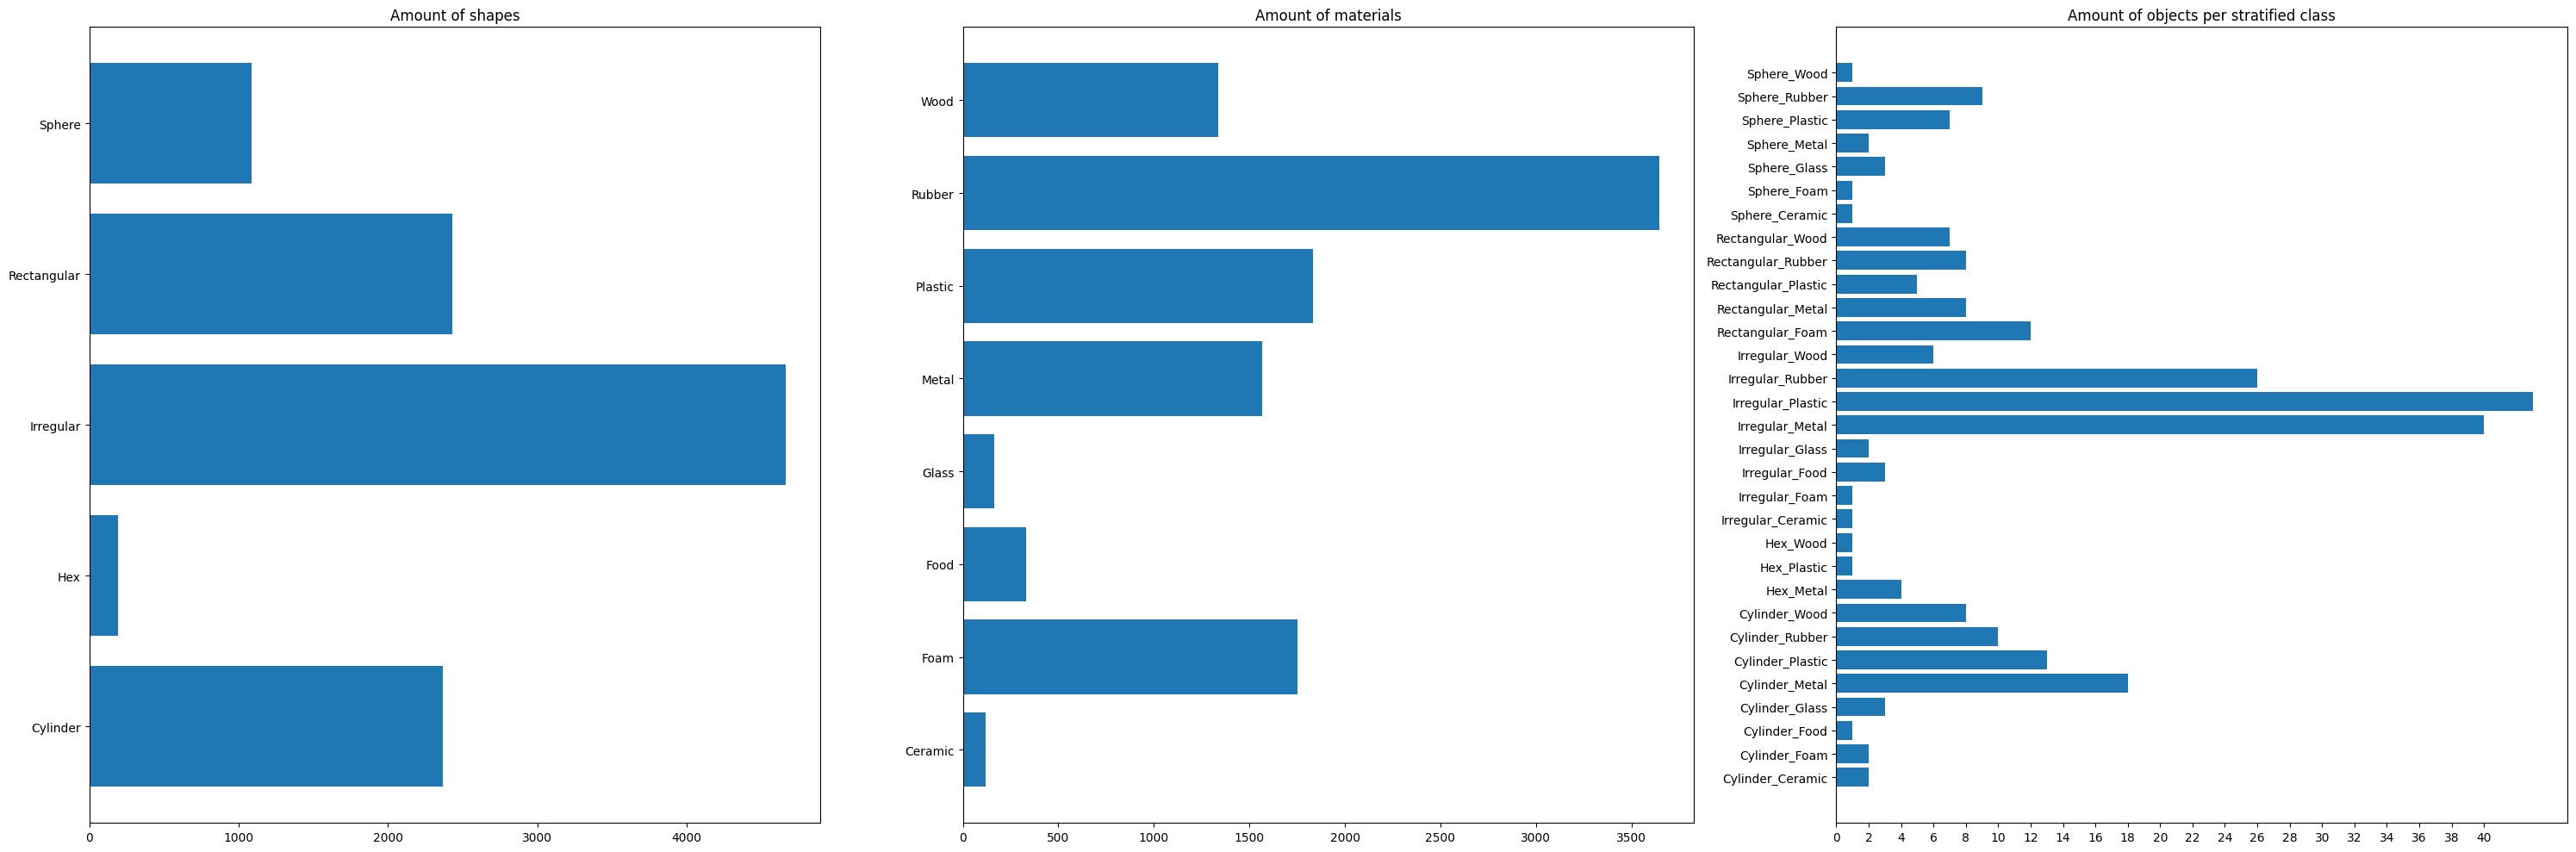

In [ ]:
from collections import Counter
import tqdm

data_module.make_object_attributes()
all_object_names = []
for loader in [data_module.train_dataloader(apply_augmentations=False), data_module.val_dataloader(apply_augmentations=False), data_module.test_dataloader(apply_augmentations=False)]:
    for batch in tqdm.tqdm(loader):
        x_frames, force, width, estimation, y, object_name = batch
        # print(x_frames.size())
        all_object_names.append(object_name[0])

full_materials = []
full_shapes = []
for object in all_object_names:
    full_materials.append(f"{data_module.object_to_material[object]}")
    full_shapes.append(f"{data_module.object_to_shape[object]}")
train_counted_material = Counter(full_materials)
train_counted_shapes = Counter(full_shapes)


all_object_names = list(set(all_object_names))
all_stratified_classes = []
for object in all_object_names:
    all_stratified_classes.append(f"{data_module.object_to_shape[object]}_{data_module.object_to_material[object]}")

train_counted_classes = Counter(all_stratified_classes)

print(train_counted_classes)
to_small_classes = []
for key in train_counted_classes.keys():
    if train_counted_classes[key] < 10:
        to_small_classes.append(key)
print(to_small_classes)
print(len(all_object_names))

val_values = []
all_names = sorted(train_counted_shapes.keys())
for name in all_names:
    val_values.append(train_counted_shapes[name])
axis[0].set_title("Amount of shapes")
axis[0].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/train_shape_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

val_values = []
all_names = sorted(train_counted_material.keys())
for name in all_names:
    val_values.append(train_counted_material[name])
axis[1].set_title("Amount of materials")
axis[1].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/train_material_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
# plt.show()

train_values = []
all_names = sorted(all_counted_classes.keys())
for name in all_names:
    train_values.append(train_counted_classes[name])
axis[2].set_title("Amount of objects per stratified class")
axis[2].barh(all_names, train_values)
axis[2].set_xticks([i for i in range(0, 41, 2)])
#plt.tight_layout()
#plt.savefig("../figures/train_stratified_classes.png", dpi=300)
f.tight_layout()
f.savefig("../figures/full_dataset_distribution.pdf", dpi=300)
f

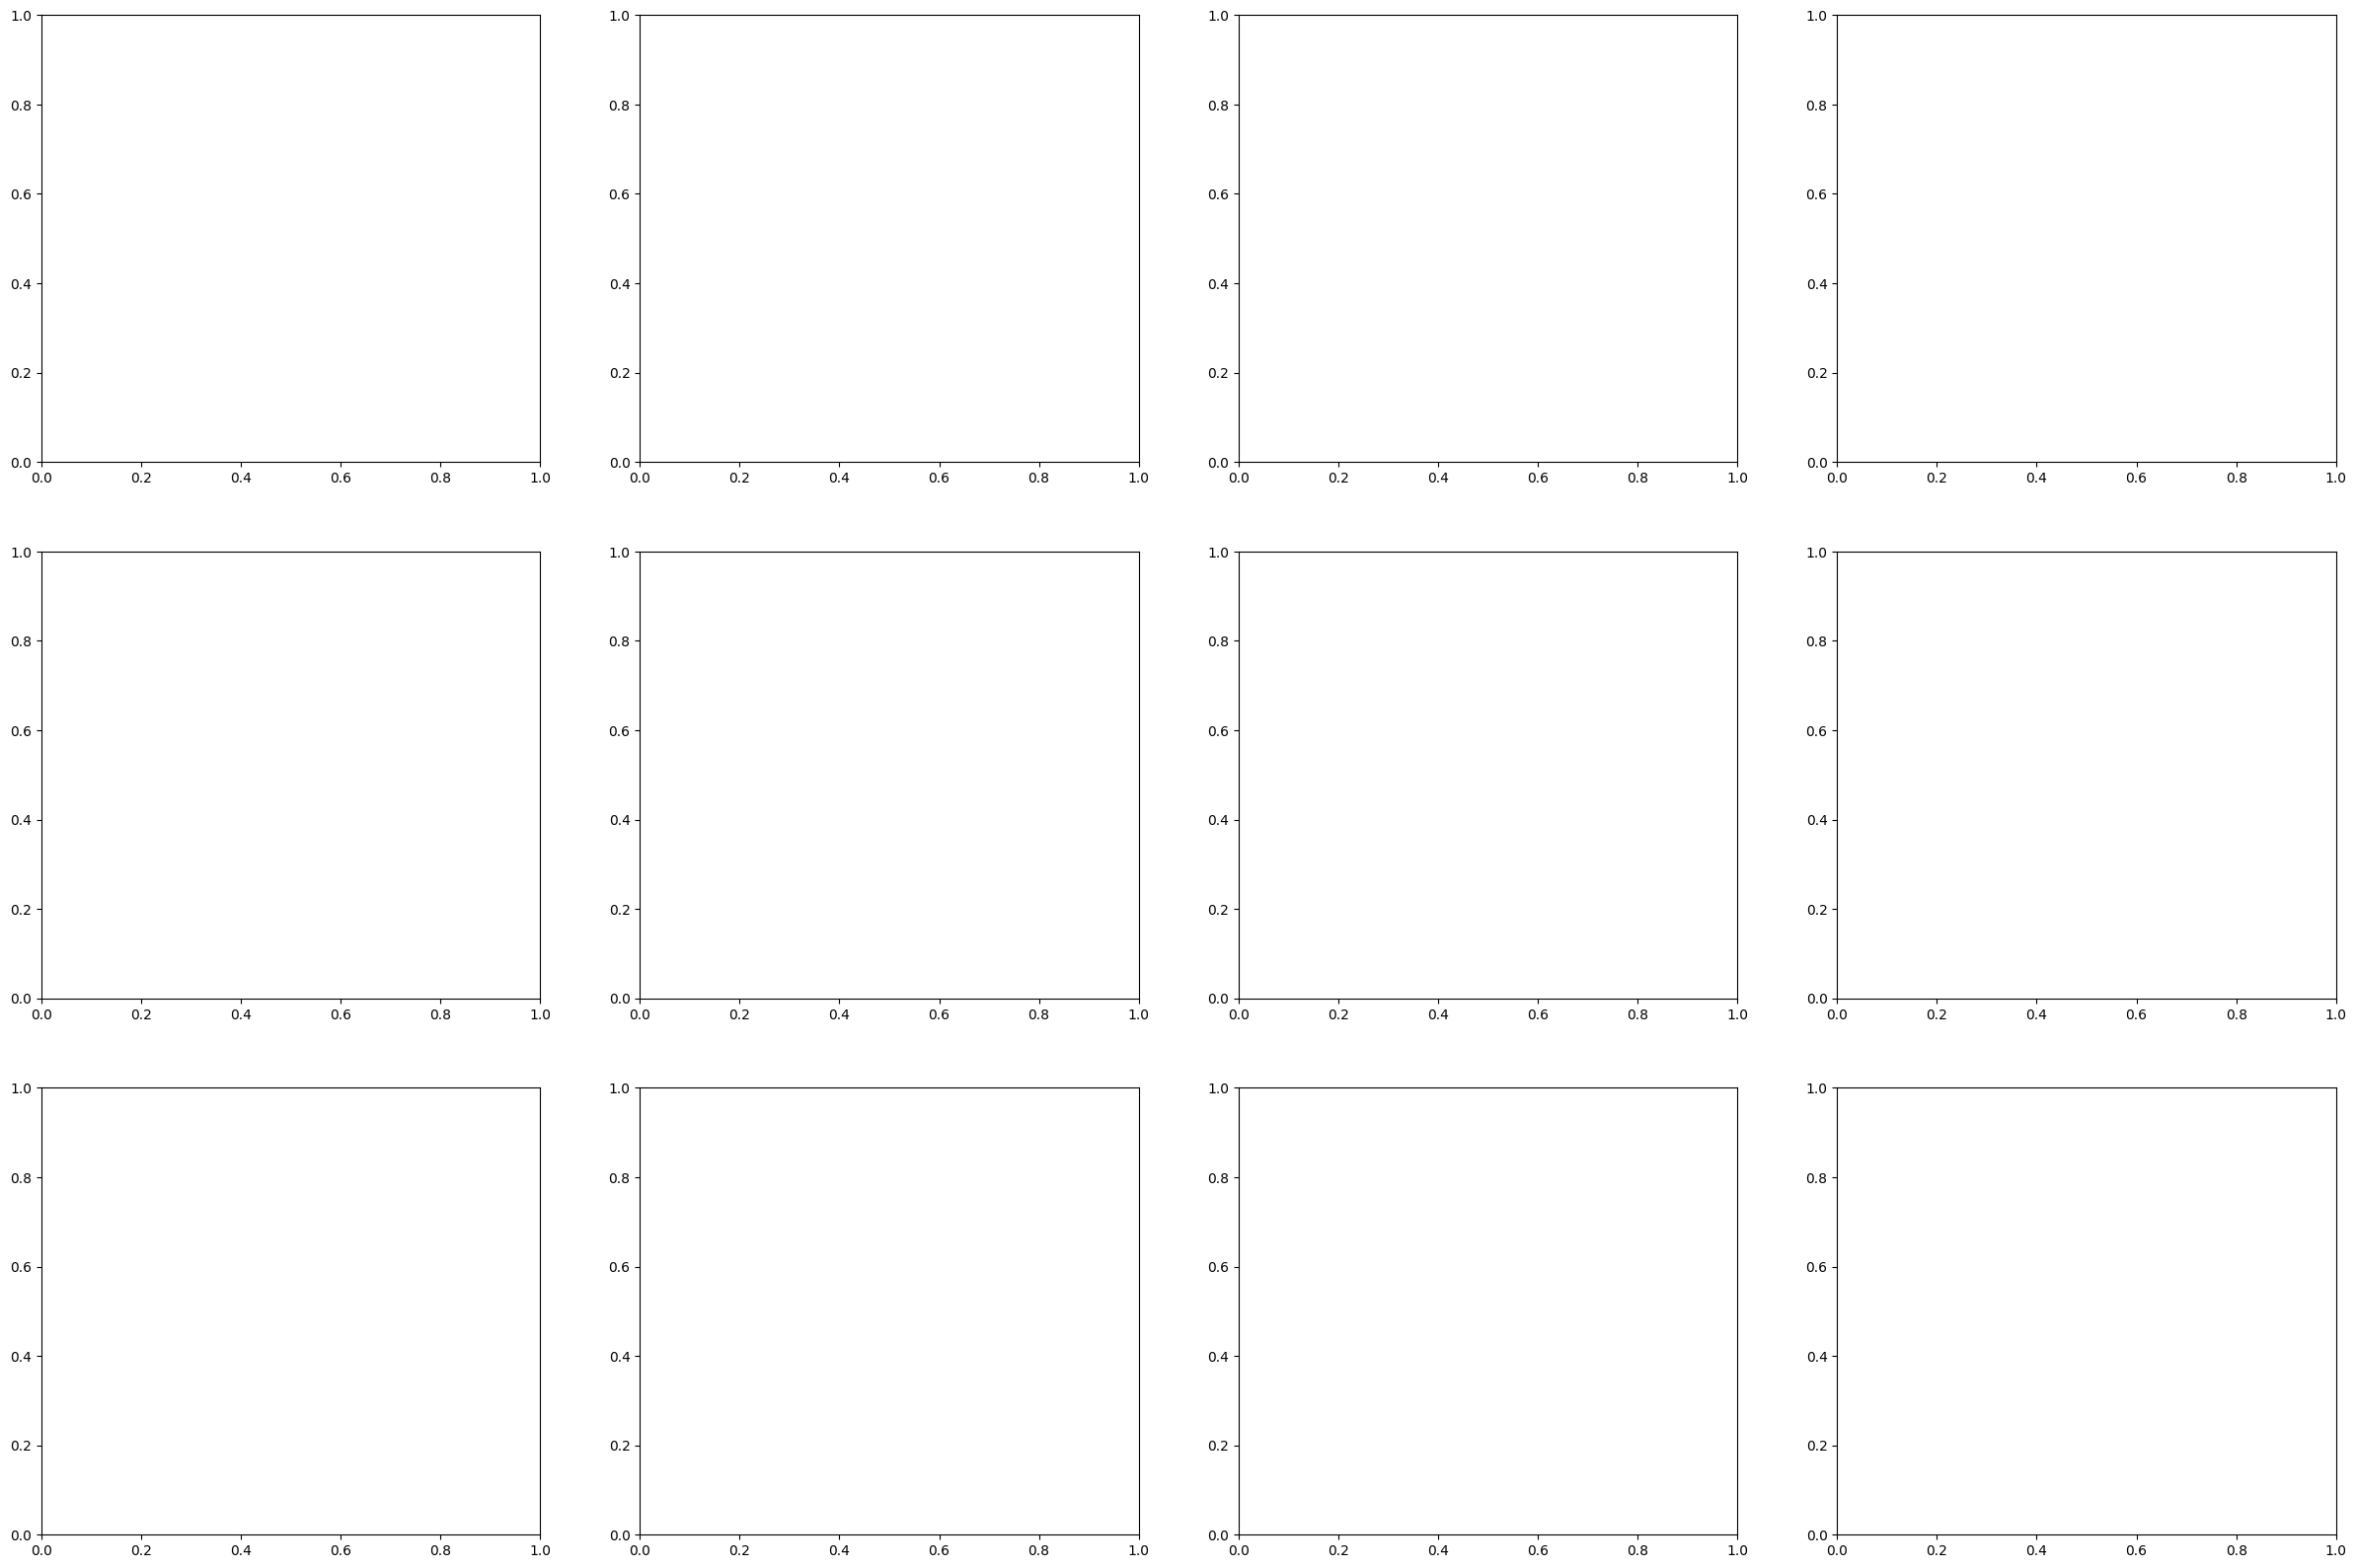

In [ ]:
import matplotlib.pyplot as plt

f, axis = plt.subplots(3,4, figsize=(30,20))


In [ ]:
from collections import Counter

data_module.make_object_attributes()
all_object_names = []
all_y = []
for loader in [data_module.train_dataloader(apply_augmentations=False)]:#, data_module.test_dataloader()]:
    for batch in loader:
        x_frames, force, width, estimation, y, object_name = batch
        all_object_names.append(object_name[0])

        all_y.append(data_module.unnormalization_function(y[0][0].detach().numpy()))

all_y = np.array(all_y)
all_y = np.log10(all_y)

full_materials = []
full_shapes = []
for object in all_object_names:
    full_materials.append(f"{data_module.object_to_material[object]}")
    full_shapes.append(f"{data_module.object_to_shape[object]}")
train_counted_material = Counter(full_materials)
train_counted_shapes = Counter(full_shapes)


all_object_names = list(set(all_object_names))
all_stratified_classes = []
for object in all_object_names:
    all_stratified_classes.append(f"{data_module.object_to_shape[object]}_{data_module.object_to_material[object]}")

train_counted_classes = Counter(all_stratified_classes)

print(train_counted_classes)
to_small_classes = []
for key in train_counted_classes.keys():
    if train_counted_classes[key] < 10:
        to_small_classes.append(key)
print(to_small_classes)
print(len(all_object_names))

val_values = []
all_names = sorted(train_counted_shapes.keys())
for name in all_names:
    val_values.append(train_counted_shapes[name])
axis[0, 0].set_title("Amount of shapes")
axis[0, 0].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/train_shape_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

val_values = []
all_names = sorted(train_counted_material.keys())
for name in all_names:
    val_values.append(train_counted_material[name])
axis[0, 1].set_title("Amount of materials")
axis[0, 1].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/train_material_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
# plt.show()

train_values = []
all_names = sorted(all_counted_classes.keys())
for name in all_names:
    train_values.append(train_counted_classes[name])
axis[0, 2].set_title("Amount of objects per stratified class")
axis[0, 2].barh(all_names, train_values)

axis[0, 3].set_title("Distribution of Young's Modulus")
axis[0, 3].hist(all_y, bins=bins)
#plt.tight_layout()
#plt.savefig("../figures/train_stratified_classes.png", dpi=300)
#f.tight_layout()
#f

Counter({'Irregular_Plastic': 43, 'Irregular_Metal': 40, 'Irregular_Rubber': 26, 'Cylinder_Metal': 18, 'Cylinder_Plastic': 13, 'Rectangular_Foam': 12, 'Cylinder_Rubber': 10, 'Sphere_Rubber': 9, 'Rectangular_Rubber': 8, 'Rectangular_Metal': 8, 'Cylinder_Wood': 8, 'Sphere_Plastic': 7, 'Rectangular_Wood': 7, 'Irregular_Wood': 6, 'Rectangular_Plastic': 5, 'Hex_Metal': 4, 'Sphere_Glass': 3, 'Cylinder_Glass': 3, 'Irregular_Food': 3, 'Sphere_Metal': 2, 'Cylinder_Foam': 2, 'Irregular_Glass': 2, 'Cylinder_Ceramic': 2, 'Hex_Plastic': 1, 'Irregular_Ceramic': 1, 'Irregular_Foam': 1, 'Sphere_Ceramic': 1, 'Sphere_Foam': 1, 'Hex_Wood': 1, 'Sphere_Wood': 1, 'Cylinder_Food': 1})
['Rectangular_Rubber', 'Sphere_Rubber', 'Sphere_Glass', 'Rectangular_Metal', 'Irregular_Wood', 'Sphere_Plastic', 'Cylinder_Glass', 'Rectangular_Plastic', 'Sphere_Metal', 'Hex_Plastic', 'Cylinder_Wood', 'Cylinder_Foam', 'Irregular_Ceramic', 'Irregular_Glass', 'Hex_Metal', 'Rectangular_Wood', 'Cylinder_Ceramic', 'Irregular_Foam',

(array([500., 500., 500., 500., 500., 500., 777., 500., 998.]),
 array([ 3.69897008,  4.54824257,  5.3975153 ,  6.24678755,  7.0960598 ,
         7.94533253,  8.79460526,  9.64387703, 10.49314976, 11.34242249]),
 <BarContainer object of 9 artists>)

In [ ]:
from collections import Counter

data_module.make_object_attributes()
all_object_names = []
all_y = []
for loader in [data_module.val_dataloader(apply_augmentations=False)]:#, data_module.test_dataloader()]:
    for batch in loader:
        x_frames, force, width, estimation, y, object_name = batch
        all_object_names.append(object_name[0])

        all_y.append(y[0][0].detach().numpy())

all_y = np.array(all_y)
all_y = np.log10(all_y)

val_counted_objects = Counter(all_object_names)
full_materials = []
full_shapes = []
for object in all_object_names:
    full_materials.append(f"{data_module.object_to_material[object]}")
    full_shapes.append(f"{data_module.object_to_shape[object]}")
val_counted_materials = Counter(full_materials)
val_counted_shapes = Counter(full_shapes)

all_object_names = list(set(all_object_names))
all_stratified_classes = []
for object in all_object_names:
    all_stratified_classes.append(f"{data_module.object_to_shape[object]}_{data_module.object_to_material[object]}")

val_counted_classes = Counter(all_stratified_classes)
print(val_counted_objects)
print(val_counted_classes)
to_small_classes = []
for key in val_counted_classes.keys():
    if val_counted_classes[key] < 10:
        to_small_classes.append(key)
print(to_small_classes)
print(len(all_object_names))

val_values = []
all_names = sorted(val_counted_shapes.keys())
for name in all_names:
    val_values.append(val_counted_shapes[name])
axis[1,0].set_title("Amount of shapes")
axis[1,0].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/val_shape_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

val_values = []
all_names = sorted(val_counted_materials.keys())
for name in all_names:
    val_values.append(val_counted_materials[name])
axis[1,1].set_title("Amount of material")
axis[1,1].barh(all_names, val_values)
#plt.tight_layout()
#plt.savefig("../figures/val_material_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

val_values = []
all_names = sorted(all_counted_classes.keys())
for name in all_names:
    val_values.append(val_counted_classes[name])
axis[1,2].set_title("Amount of Objects with stratified_labels")
axis[1,2].barh(all_names, val_values)
axis[1,2].set_xticks([i for i in range(0, max(all_counted_classes.values()), 5)])

axis[1, 3].set_title("Distribution of Young's Modulus")
axis[1, 3].hist(all_y, bins=bins)

#plt.tight_layout()
#plt.savefig("../figures/val_stratified_classes.png", dpi=300)
#plt.show()

Counter({'plastic_measuring_cup': 167, 'cork': 167, 'black_donut_indenter': 167, 'rubber_spatula': 167, 'charger_cable': 166, 'whiteboard_eraser': 166, 'stuffed_animal': 63, 'red_foam_brick': 63, 'marshmallow': 63, 'black_foam': 63, 'pillow': 62, 'blue_foam_brick': 62, 'orange_elastic_ball': 62, 'yellow_foam_brick': 62, 'foam_sticker_stack': 42, 'gel_big': 42, 'blue_elastic_ball': 42, 'rubber_egg': 42, 'red_elastic_ball': 42, 'gummy_bear': 42, 'purple_elastic_ball': 42, 'green_elastic_ball': 42, 'lifesaver_gummy': 41, 'green_foam_brick': 41, 'gel_double_wide': 41, 'yellow_sponge': 41, 'insole': 30, 'rubber_pancake': 30, 'gel': 30, 'rubber_band': 30, 'foam_square': 30, 'rubber_band_bundle': 30, 'styrofoam_cylinder': 30, 'molded_cylinder_wide': 29, 'scotch_brite': 29, 'foam_brick': 29, 'molded_rectangle': 29, 'molded_cylinder_thin': 29, 'foam_banana': 29, 'magnetic_whiteboard_eraser': 29, 'green_rubber_donut': 29, 'foam_rod': 29, 'foam_earth': 29, 'wooden_cube': 24, 'chopstick': 24, 'pla

(array([ 124.,  189.,  187.,  291.,  474.,  632.,  436.,  762., 1405.]),
 array([-1.10978401, -0.99013585, -0.87048763, -0.75083947, -0.63119125,
        -0.5115431 , -0.39189488, -0.27224669, -0.1525985 , -0.03295032]),
 <BarContainer object of 9 artists>)

In [ ]:
from collections import Counter

data_module.make_object_attributes()
all_object_names = []
all_y = []
for loader in [data_module.test_dataloader(apply_augmentations=False)]:#, data_module.test_dataloader()]:
    for batch in loader:
        x_frames, force, width, estimation, y, object_name = batch
        all_object_names.append(object_name[0])

        all_y.append(data_module.unnormalization_function(y[0][0].detach().numpy()))

all_y = np.array(all_y)
all_y = np.log10(all_y)

test_counted_objects = Counter(all_object_names)
full_materials = []
full_shapes = []
for object in all_object_names:
    full_materials.append(f"{data_module.object_to_material[object]}")
    full_shapes.append(f"{data_module.object_to_shape[object]}")
test_counted_materials = Counter(full_materials)
test_counted_shapes = Counter(full_shapes)

all_object_names = list(set(all_object_names))
all_stratified_classes = []
for object in all_object_names:
    all_stratified_classes.append(f"{data_module.object_to_shape[object]}_{data_module.object_to_material[object]}")

test_counted_classes = Counter(all_stratified_classes)
print(test_counted_objects)
print(test_counted_classes)
to_small_classes = []
for key in test_counted_classes.keys():
    if test_counted_classes[key] < 10:
        to_small_classes.append(key)
print(to_small_classes)
print(len(all_object_names))

test_values = []
all_names = sorted(test_counted_shapes.keys())
for name in all_names:
    test_values.append(test_counted_shapes[name])
axis[2,0].set_title("Amount of shapes")
axis[2,0].barh(all_names, test_values)
#plt.tight_layout()
#plt.savefig("../figures/test_shape_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

test_values = []
all_names = sorted(test_counted_materials.keys())
for name in all_names:
    test_values.append(test_counted_materials[name])
axis[2,1].set_title("Amount of material")
axis[2,1].barh(all_names, test_values)
#plt.tight_layout()
#plt.savefig("../figures/test_material_dist.png", dpi=300)
# plt.xticks([i for i in range(0, max(all_counted_classes.values()), 5)])
#plt.show()

test_values = []
all_names = sorted(all_counted_classes.keys())
for name in all_names:
    test_values.append(test_counted_classes[name])
axis[2,2].set_title("Amount of Objects with stratified_labels")
axis[2,2].barh(all_names, test_values)
axis[2,2].set_xticks([i for i in range(0, max(all_counted_classes.values()), 5)])


axis[2, 3].set_title("Distribution of Young's Modulus")
axis[2, 3].hist(all_y, bins=bins)
#plt.tight_layout()
#plt.savefig("../figures/test_stratified_classes.png", dpi=300)
#plt.show()

Counter({'black_foam': 14, 'purple_elastic_ball': 12, 'rubber_rope': 12, 'rubber_pancake': 11, 'rubber_band': 11, 'green_elastic_ball': 11, 'allen_key_medium': 10, 'marshmallow': 10, 'foam_brick': 9, 'rubber_band_ball': 9, 'screw': 9, 'molded_cylinder_thin': 9, 'metal_fork': 9, 'chopstick': 9, 'yellow_sponge': 9, 'bolt_gray_long': 9, 'allen_key_small': 9, 'foam_sticker_stack': 9, 'plastic_measuring_cup': 8, 'orange_elastic_ball': 8, 'wooden_double_arch': 8, 'blue_foam_brick': 8, 'blue_elastic_ball': 8, 'plastic_fork': 8, 'styrofoam_cylinder': 8, 'plastic_spoon': 7, 'rubber_band_bundle': 7, 'foam_banana': 7, 'wooden_dowel_tiny': 7, 'baby_lego_2': 7, 'xacto_knife': 7, 'ladle_simple': 7, 'yellow_foam_brick': 7, 'foam_square': 7, 'charger_cable': 7, 'unthreaded_screw': 7, 'plastic_fork_white': 7, 'banana_eraser': 7, 'pencil': 6, 'u_bracket': 6, 'lifesaver_gummy': 6, 'wooden_spoon': 6, 'bolt_gray': 6, 'stuffed_animal': 6, 'bolt_black_big': 6, 'bowl_big_plastic': 6, 'zebra_eraser': 6, 'baby_

(array([ 63.,  74.,  98., 105.,  13.,   9., 231.,  96., 286.]),
 array([ 3.69897008,  4.54824257,  5.3975153 ,  6.24678755,  7.0960598 ,
         7.94533253,  8.79460526,  9.64387703, 10.49314976, 11.34242249]),
 <BarContainer object of 9 artists>)

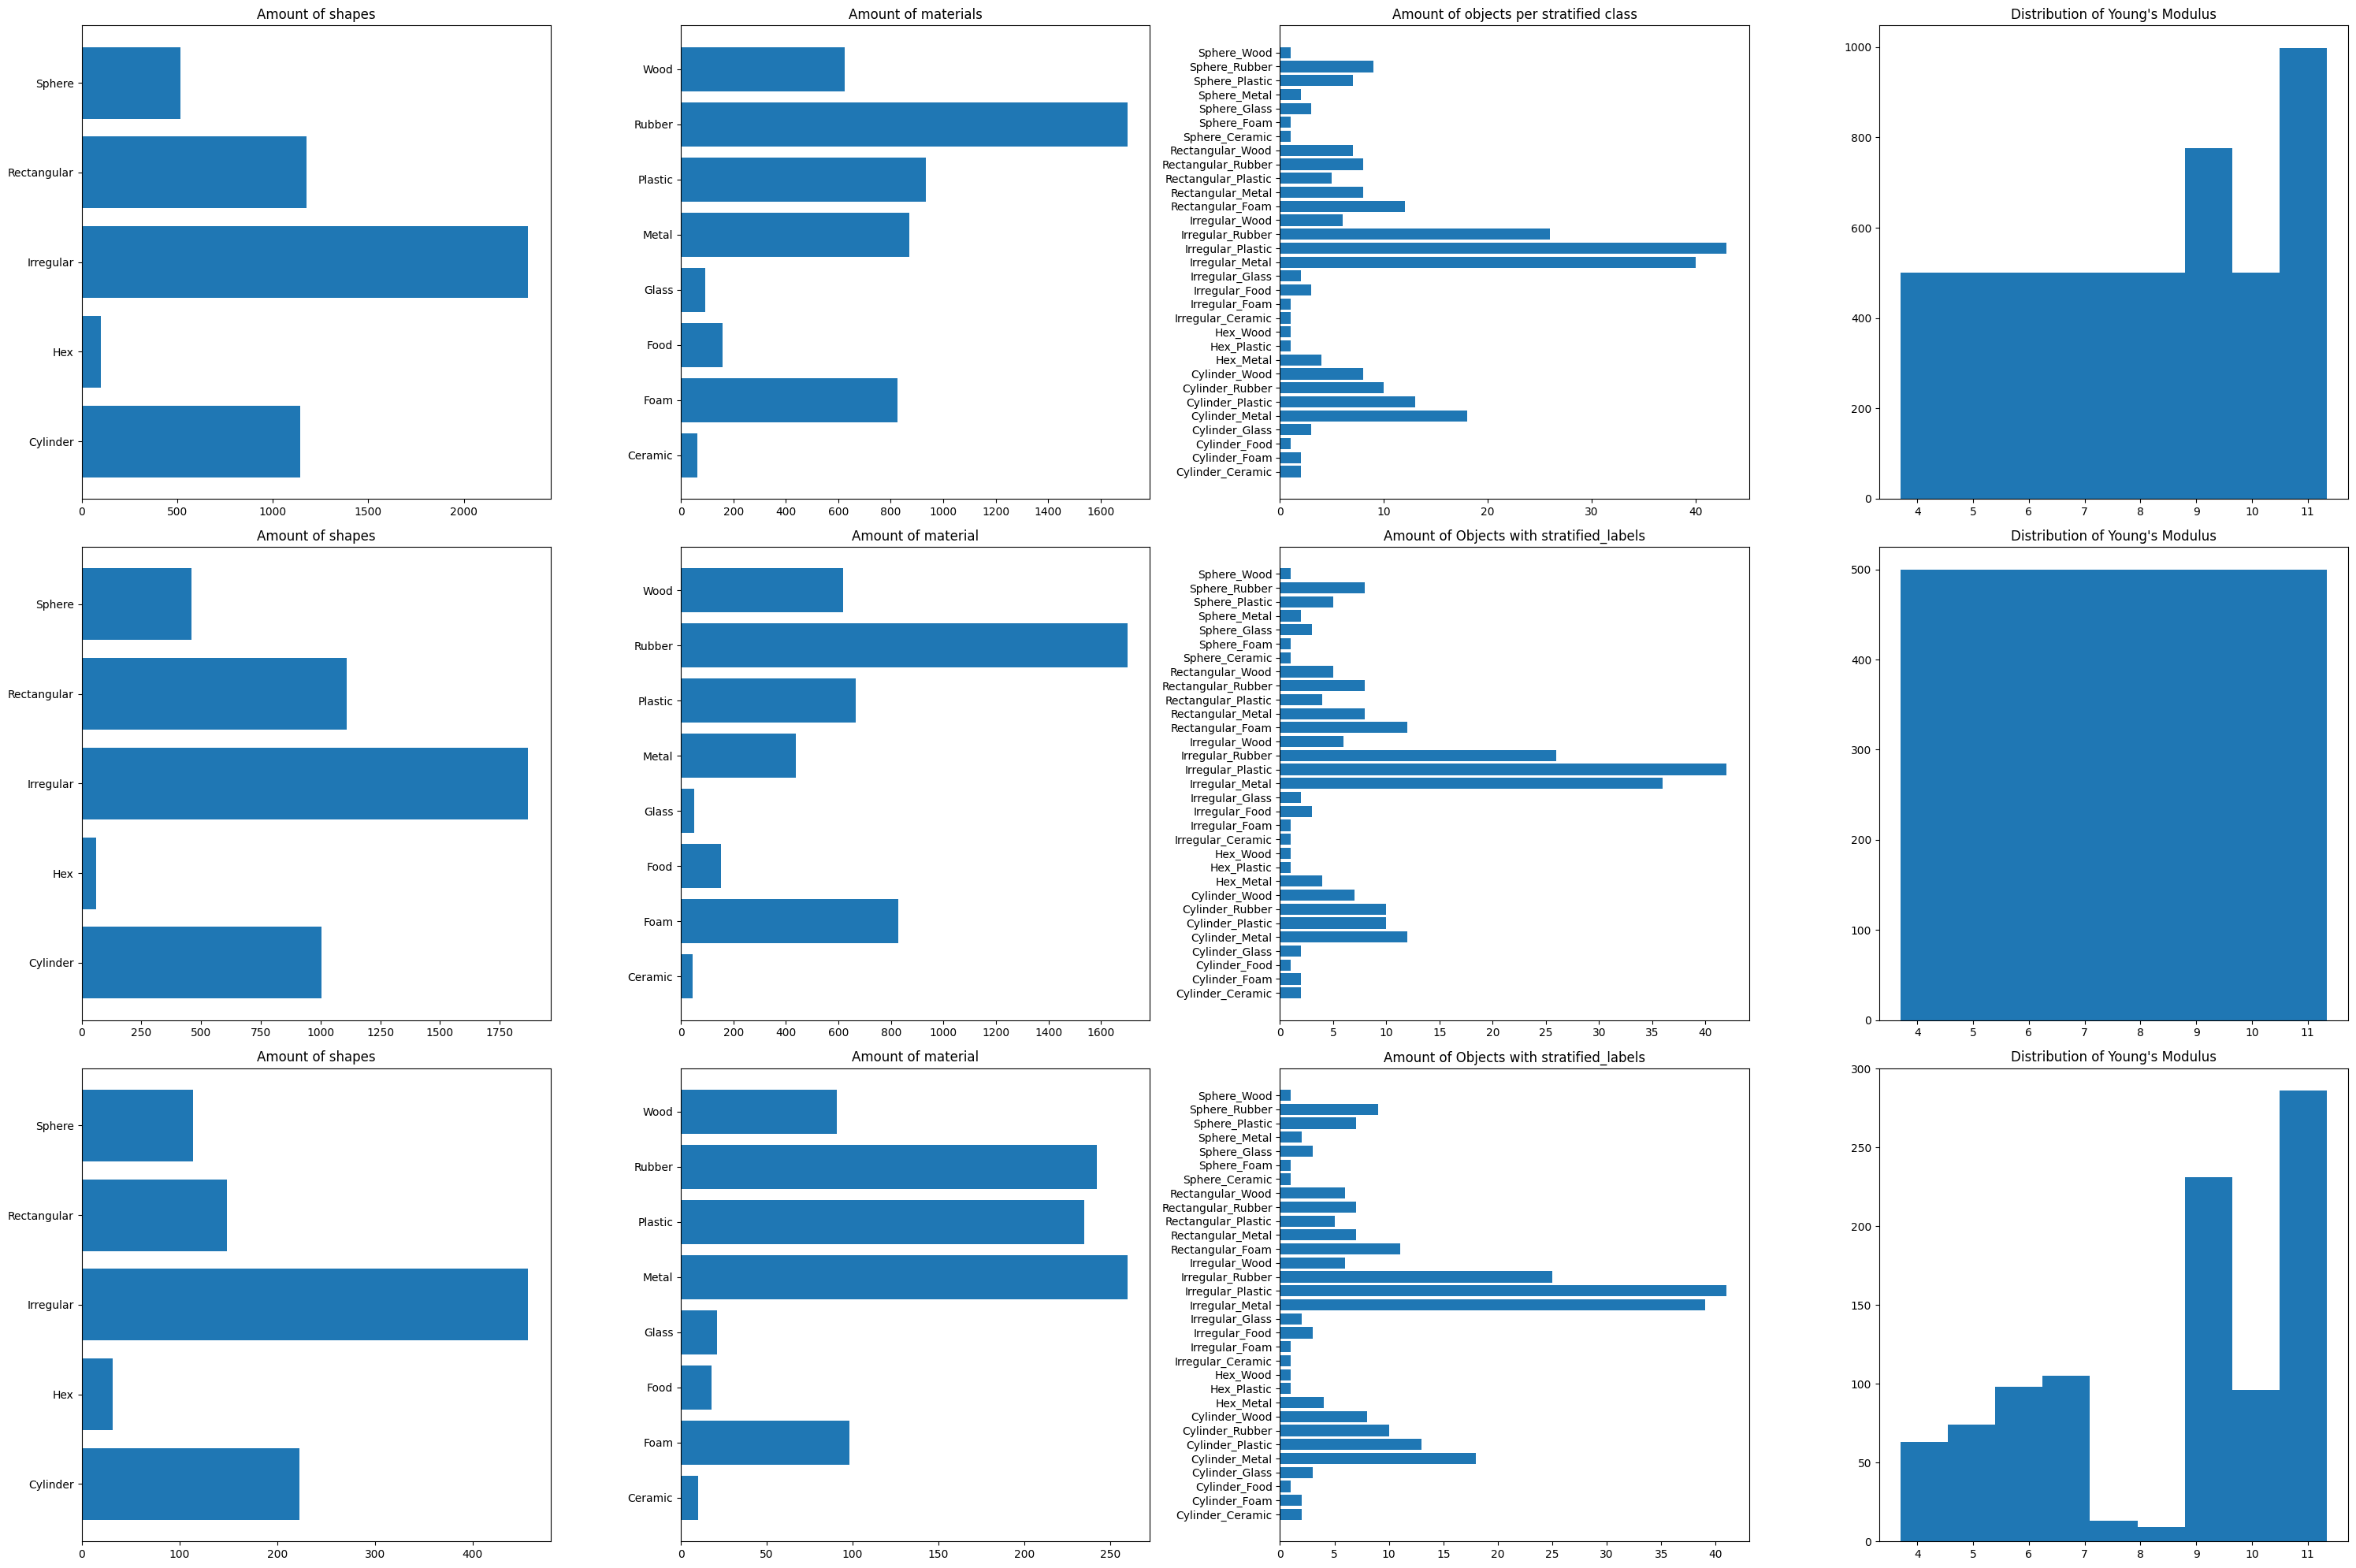

In [ ]:
f.tight_layout()
f.savefig("../figures/dataset_distribution.pdf", dpi=300)
f

In [ ]:
data_module.make_object_attributes()
all_objects = []
all_shapes = []
all_materials = []
all_moduli = []

for loader in [data_module.train_dataloader(), data_module.val_dataloader(), data_module.test_dataloader()]:
    for batch in loader:
        x_frames, force, width, estimation, y, object_name = batch
        object_name = object_name[0]
        y = data_module.object_to_modulus[object_name]
        shape = data_module.object_to_shape[object_name]
        material = data_module.object_to_material[object_name]
        all_objects.append(object_name)
        all_shapes.append(shape)
        all_materials.append(material)
        all_moduli.append(y)
        # print(f"{object_name} {shape} {material} {y}")

b_dict = {

}

for i in range (len(all_shapes)):
    if all_shapes[i] not in b_dict:
        b_dict[all_shapes[i]] = {
            "all_materials": [],
            "all_moduli": [],
        }
    
    b_dict[all_shapes[i]]["all_materials"].append(all_materials[i])
    b_dict[all_shapes[i]]["all_moduli"].append(all_moduli[i])
    



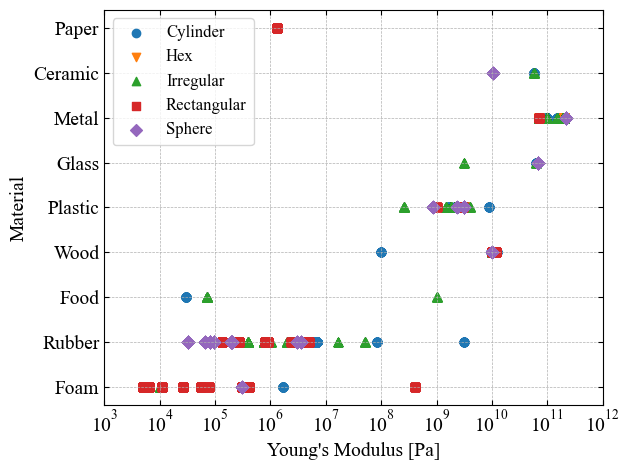

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Times New Roman'
font = 14
plt.figure()
ticks_y = list(set(all_materials))
markers = ["o", "v", "^", "s", "D"]
tick_order = ["Foam", "Rubber", "Food", "Wood", "Plastic", "Glass", "Metal", "Ceramic", "Paper"]
shape_order =["Cylinder", "Hex", "Irregular", "Rectangular", "Sphere"]
for key, marker in zip(shape_order, markers):
    a_mat = np.array(b_dict[key]["all_materials"])
    a_mod = np.array(b_dict[key]["all_moduli"])

    sorted_mat = []
    sorted_mod = []
    for k in tick_order:
        mask = a_mat == k
        sorted_mat.append(a_mat[mask])
        sorted_mod.append(a_mod[mask])

    sorted_mat = np.concatenate(sorted_mat)
    sorted_mod = np.concatenate(sorted_mod)
    plt.scatter(sorted_mod, sorted_mat, label=key, marker=marker)
    # plt.scatter(all_moduli, all_materials)
plt.xscale('log')
#plt.yscale('log')

# Set the same ticks for both axes
ticks = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]

plt.xticks(ticks, fontsize=font)
plt.yticks(tick_order, fontsize=font)
plt.minorticks_off()
# Enable ticks on all sides and point them inside
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Add grid lines (raster)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.xlabel("Young's Modulus [Pa]", fontsize=font)
plt.ylabel("Material", fontsize=font)

plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../figures/youngs_modulus_materials.pdf", dpi=300, format="pdf")
plt.show()

In [ ]:
import cv2 as cv
import numpy as np

index = 0
for batch in data_module.test_dataloader():

    #print(batch[0].shape)
    image = np.moveaxis(batch[0][0].numpy(), 1, -1)
    # print(image.shape)
    image = image * 255
    
    cv.imwrite('test1.png', image[0])
    cv.imwrite('test2.png', image[1])
    cv.imwrite('test3.png', image[2])
    if index == 6:
        break
    index += 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.009803922..0.7352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07254902..0.74313724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12352941..0.89215684].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15882353..0.90392154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.029411765..0.79019606].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.021568628..0.7862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got ran

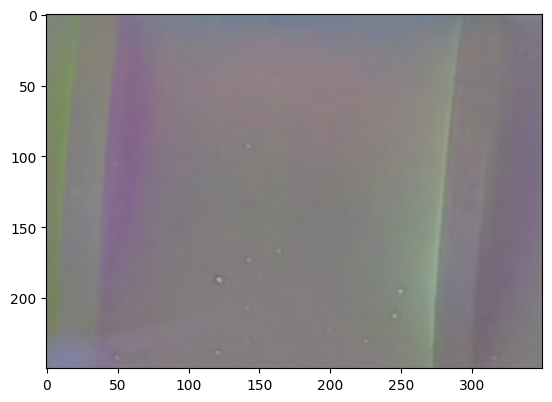

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as ani
import numpy as np

fig = plt.figure()
index = 0
frames = []
for batch in data_module.test_dataloader():
    index += 1
    #print(batch[0].shape)
    image = np.moveaxis(batch[0][0].numpy(), 1, -1)
    #print(image.shape)
    frames.append([plt.imshow(image[0], animated=True)])
    frames.append([plt.imshow(image[1], animated=True)])
    frames.append([plt.imshow(image[2], animated=True)])
    if index > 1000:
        break

ani = ani.ArtistAnimation(fig, frames, interval=12, blit=True, repeat_delay=1000)
ani.save('../data/movie.gif')
plt.show()

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

import tqdm
def get_stats(dataloader):
    objects = []
    for batch in tqdm.tqdm(dataloader):
        x_frames, x_forces, x_widths, x_estimations, y, object_names = batch
        objects.append(object_names[0])

    return Counter(objects)

stats = get_stats(data_module.train_dataloader())
stats.update(get_stats(data_module.val_dataloader()))
stats.update(get_stats(data_module.test_dataloader()))
print(max(stats.values()))
print(min(stats.values()))
t = list(stats.values())
t.sort()
print(t)

excluded = ['playdoh', 'silly_puty', 'blue_sponge_dry', 'blue_sponge_wet', 'apple', 'orange', 'strawberry', 'ripe_banana', 'unripe_banana', 'lacrosse_ball', 'baseball', 'racquet_ball', 'tennis_ball']

excluded_stats = [stats[n] for n in excluded]
print(excluded_stats)

#plt.bar(get_stats(data_module.train_dataloader()).keys(), get_stats(data_module.train_dataloader()).values())
#plt.show()


In [ ]:
import matplotlib.pyplot as plt

youngs_modulus_values = []

for batch in data_module.train_dataloader():
    _, _, _, _, y, _ = batch
    youngs_modulus_values.extend(data_module.log_unnormalize(y).numpy().flatten())

plt.figure(figsize=(10, 6))
plt.hist(youngs_modulus_values, bins=50, alpha=0.75)
plt.xlabel('Young\'s Modulus')
plt.ylabel('Frequency')
plt.title('Distribution of Young\'s Modulus in the Dataset')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(youngs_modulus_values, youngs_modulus_values, marker='o', alpha=0.75)
plt.xlabel('Young\'s Modulus')
plt.ylabel('Young\'s Modulus')
plt.title('Young\'s Modulus Values on a Linear Line')
plt.show()

Evaluation

VGG-LSTM

In [ ]:
from pathlib import Path
path_to_checkpoint = Path("/home/malte.kuhlmann/youngs-modulus/checkpoint_good/res_tf/fold_2/res_tf_shape_material_unseen_force_width_transforms_log_normalize_removed_paper_random_state_42_shape_material.ckpt").resolve()

In [ ]:
from model.VGG_LSTM.modulus_model import ModulusModel

model = ModulusModel.load_from_checkpoint(path_to_checkpoint)
model.eval()
model = model.cuda(0)

model_config = model.config
print(model_config)

AttributeError: 'AttributeDict' object has no attribute 'input_dim'

In [ ]:
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule

data_module = KFoldYoungsDataModule(
    data_dir=model_config['data_dir'],
    training_data_folder=model_config['training_data_folder'],
    # n_frames=model_config['n_frames'],
    #img_size=model_config['img_size'],
    worker=5,
    image_style=model_config['img_style'],
    sample_type=model_config['sample_type'],
    use_estimations=model_config['use_estimations'],
    use_force=model_config['use_force'],
    use_width=model_config['use_width'],
    use_width_transforms=model_config['use_width_transforms'],
    use_markers=model_config['use_markers'],
    use_log_normalization=model_config['use_log_normalization'],
    val_on_seen_objects=model_config['val_on_seen_objects'],
    overwrite_file=False,
    batch_size=1,
    exclude=model_config['exclude'],
)
data_module.prepare_data()
data_module.setup(fold=2)

In [ ]:
import torch
import tqdm
import numpy as np

data = data_module.test_dataloader()

stats = {
    "loss": [],
    "abs_log_diff": [],
    "log_accuracy": [],
}

for batch in tqdm.tqdm(data):
    x_frames, x_forces, x_widths, x_estimations, y, _ = batch
    batch_size = x_frames.shape[0]
    y = y.squeeze()
    outputs = model.forward(x_frames.cuda(), x_forces.cuda(), x_widths.cuda(), x_estimations.cuda(), x_frames.shape[0])
    outputs = outputs.squeeze()
    loss = torch.nn.functional.mse_loss(outputs, y.cuda()).cpu()
    abs_log_diff = torch.abs(torch.log10(model.unnormalization_function(outputs.cpu())) - torch.log10(model.unnormalization_function(y.cpu()))).detach().numpy()


    stats["log_accuracy"].append(1 if (abs_log_diff <= 1) else 0)
    stats["loss"].append(loss.detach().numpy())
    stats["abs_log_diff"].append(abs_log_diff)

stats["mse_loss"] = np.mean(stats["loss"])
stats["abs_log_diff"] = np.mean(stats["abs_log_diff"])
stats["log_accuracy"] = np.mean(stats["log_accuracy"])
stats["loss"] = np.mean(stats["loss"])

In [ ]:
print(stats)

## Res_TF

In [ ]:
from pathlib import Path
path_to_checkpoint = Path("/home/malte.kuhlmann/youngs-modulus/checkpoint_good/res_tf/fold_1/res_tf_shape_material_seen_force_width_transforms_log_normalize_removed_paper_random_state_42_shape_material.ckpt").resolve()

In [ ]:
from model.Res_TF.modulus_model import ModulusModel

model = ModulusModel.load_from_checkpoint(path_to_checkpoint)
model = model.eval()
model = model.cuda(0)

model_config = model.config
print(model_config)

Using log normalization
{'gamma': 0.955, 'learning_rate': 0.0001, 'lr_step_size': 1, 'random_state': 42, 'batch_size': 64, 'use_fair_loss': False, 'video_dropout': 0.4, 'force_dropout': 0.1, 'width_dropout': 0.1, 'est_dropout': 0.3, 'decoder_dropout': 0.2, 'fwe_feature_size': 16, 'decoder_size': [64, 64, 32], 'est_decoder_size': [32, 32, 16], 'decoder_output_size': 8, 'layer': 6, 'head': 2, 'embedding_dim': 256, 'output_dim': 1024, 'data_dir': '/home/malte.kuhlmann/youngs-modulus/data', 'training_data_folder': 'gelsight_youngs_modulus_dataset', 'sample_type': 'shape_material', 'n_channels': 3, 'n_frames': 3, 'img_size': [250, 350], 'img_style': 'RGB', 'val_on_seen_objects': True, 'use_force': True, 'use_width': False, 'use_estimations': False, 'use_transformations': True, 'use_width_transforms': True, 'use_log_normalization': True, 'use_markers': False, 'rubber_only': False, 'remove_paper': True, 'exclude': ['playdoh', 'silly_puty', 'blue_sponge_dry', 'blue_sponge_wet', 'apple', 'orang

Using log normalization
{'gamma': 0.965, 'learning_rate': 9e-05, 'lr_step_size': 1, 'random_state': 42, 'batch_size': 64, 'use_fair_loss': False, 'video_dropout': 0.1, 'force_dropout': 0.1, 'width_dropout': 0.1, 'est_dropout': 0.2, 'decoder_dropout': 0.1, 'fwe_feature_size': 16, 'decoder_size': [32, 32, 16], 'est_decoder_size': [512, 512, 256], 'decoder_output_size': 3, 'layer': 6, 'head': 4, 'embedding_dim': 128, 'output_dim': 256, 'data_dir': '/home/malte.kuhlmann/youngs-modulus/data', 'training_data_folder': 'gelsight_youngs_modulus_dataset', 'sample_type': 'random', 'n_channels': 3, 'n_frames': 3, 'img_size': [250, 350], 'img_style': 'RGB', 'val_on_seen_objects': True, 'use_force': True, 'use_width': False, 'use_estimations': False, 'use_transformations': True, 'use_width_transforms': True, 'use_log_normalization': True, 'use_markers': False, 'rubber_only': False, 'remove_paper': True, 'exclude': ['playdoh', 'silly_puty', 'blue_sponge_dry', 'blue_sponge_wet', 'apple', 'orange', 'strawberry', 'ripe_banana', 'unripe_banana', 'lacrosse_ball', 'baseball', 'racquet_ball', 'tennis_ball'], 'dataset_name': 'dataset_random_seen_force_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl', 'model_name': 'res_tf'}

In [ ]:
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule
fold = int(path_to_checkpoint.parent.stem.split("_")[-1])
data_module = KFoldYoungsDataModule(
        data_dir=model_config['data_dir'],
        training_data_folder=model_config['training_data_folder'],
        # n_frames=model_config['n_frames'],
        #img_size=model_config['img_size'],
        worker=5,
        image_style=model_config['img_style'],
        sample_type=model_config['sample_type'],
        use_estimations=model_config['use_estimations'],
        use_force=model_config['use_force'],
        use_width=model_config['use_width'],
        use_width_transforms=model_config['use_width_transforms'],
        use_markers=model_config['use_markers'],
        remove_paper=model_config['remove_paper'],
        overwrite_file=False,
        batch_size=1,
        val_on_seen_objects=model_config["val_on_seen_objects"],
        use_log_normalization=model_config['use_log_normalization'],
        exclude=model_config['exclude'],
    )
data_module.prepare_data()
data_module.setup(fold=fold)

/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/dataset_shape_material_unseen_width_transforms_log_normalize_removed_paper_random_state_42_shape_material_dataset.pkl
Using log normalization
Dataset already exists
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225,

In [ ]:
def check_lists_disjoint(list1, list2):
    set1 = set(list1)
    set2 = set(list2)
    
    return set1.isdisjoint(set2)

# Example usage
list1 = data_module.train_indices.tolist()
list2 = data_module.val_indices.tolist()
list3 = data_module.test_indices.tolist()

are_disjoint1 = check_lists_disjoint(list1, list2)
are_disjoint2 = check_lists_disjoint(list1, list3)
are_disjoint3 = check_lists_disjoint(list3, list2)
print(f"Are the lists disjoint? {are_disjoint1} {are_disjoint2} {are_disjoint3}")

In [ ]:
data_module.setup(fold = 6)



[88, 4866, 3914, 4019, 2277, 3500, 3031, 3820, 1800, 4159, 4744, 648, 1460, 4198, 4712, 829, 4472, 3906, 4491, 3122, 2284, 1888, 3817, 4402, 3643, 4717, 2383, 3385, 667, 2724, 1256, 3507, 4022, 4026, 2367, 581, 4812, 3256, 12, 2507, 2753, 3564, 2938, 2072, 900, 933, 4802, 4539, 4130, 4805, 2242, 3915, 1934, 345, 2621, 3587, 1, 2778, 708, 1586, 2143, 555, 2648, 1828, 2346, 4069, 3951, 1933, 4636, 982, 1362, 2605, 927, 1606, 480, 1376, 803, 2580, 536, 3228, 4394, 2081, 4277, 3068, 4667, 2790, 4138, 3301, 2586, 3276, 4231, 2552, 3151, 3481, 4291, 638, 185, 1326, 680, 1338, 1220, 3428, 4671, 4694, 1380, 2247, 3887, 1122, 462, 1367, 2545, 3027, 4723, 2374, 3338, 553, 4626, 4181, 2953, 3074, 2351, 3567, 286, 465, 2530, 3126, 2917, 3206, 4695, 4267, 622, 1298, 1412, 2106, 1366, 1470, 2091, 3253, 1759, 4565, 3420, 2631, 408, 4628, 1391, 1077, 1349, 2885, 1514, 4594, 2805, 429, 4768, 3771, 4345, 4115, 1127, 1364, 1329, 917, 1275, 2849, 1791, 2396, 2311, 3170, 248, 3238, 2034, 3844, 712, 2154, 1

In [ ]:

# Example usage
tlist1 = data_module.train_indices.tolist()
tlist2 = data_module.val_indices.tolist()
tlist3 = data_module.test_indices.tolist()

tare_disjoint1 = check_lists_disjoint(list1, list2)
tare_disjoint2 = check_lists_disjoint(list1, list3)
tare_disjoint3 = check_lists_disjoint(list3, list2)
print(f"Are the lists disjoint? {tare_disjoint1} {tare_disjoint2} {tare_disjoint3}")

In [ ]:
i = check_lists_disjoint(tlist1, list1)
j = check_lists_disjoint(tlist2, list2)
k = check_lists_disjoint(tlist3, list3)
print(i, j, k)
print(tlist1)
print(list1)

In [ ]:
import torch
import tqdm
import numpy as np

data = data_module.train_dataloader()
data_module.make_object_attributes()
model.hparams.use_transformations = False
stats = {
    "loss": [],
    "abs_log_diff": [],
    "log_accuracy": [],
    "shape_log_accuracy": {

    },
    "shape_count": {
    },
    "material_log_accuracy": {

    },
    "material_count": {
    
    }
}
for shape in set(data_module.object_to_shape.values()):
    stats["shape_log_accuracy"][shape] = []
for material in set(data_module.object_to_material.values()):
    stats["material_log_accuracy"][material] = []

for batch in tqdm.tqdm(data):
    x_frames, x_forces, x_widths, x_estimations, y, object_name = batch
    batch_size = x_frames.shape[0]
    y = y.squeeze()
    outputs = model.forward(x_frames.cuda(), x_forces.cuda(), x_widths.cuda(), x_estimations.cuda(), x_frames.shape[0])
    outputs = outputs.squeeze()
    loss = torch.nn.functional.mse_loss(outputs, y.cuda()).cpu()
    abs_log_diff = torch.abs(torch.log10(model.unnormalization_function(outputs.cpu())) - torch.log10(model.unnormalization_function(y.cpu()))).detach().numpy()


    stats["log_accuracy"].append(1 if (abs_log_diff <= 1) else 0)
    stats["shape_log_accuracy"][data_module.object_to_shape[object_name[0]]].append(1 if (abs_log_diff <= 1) else 0)
    stats["material_log_accuracy"][data_module.object_to_material[object_name[0]]].append(1 if (abs_log_diff <= 1) else 0)
    stats["loss"].append(loss.detach().numpy())
    stats["abs_log_diff"].append(abs_log_diff)

stats["mse_loss"] = np.mean(stats["loss"])
stats["abs_log_diff"] = np.mean(stats["abs_log_diff"])
for shape in sorted(list(set(data_module.object_to_shape.values()))):
    stats["shape_count"][shape] = sum(stats["shape_log_accuracy"][shape])
    stats["shape_log_accuracy"][shape] = np.mean(stats["shape_log_accuracy"][shape]) if len(stats["shape_log_accuracy"][shape]) > 0 else -1
for material in sorted(list(set(data_module.object_to_material.values()))):
    stats["material_count"][material] = sum(stats["material_log_accuracy"][material])
    stats["material_log_accuracy"][material] = np.mean(stats["material_log_accuracy"][material]) if len(stats["material_log_accuracy"][material]) > 0 else -1
stats["log_accuracy"] = np.mean(stats["log_accuracy"])
stats["loss"] = np.mean(stats["loss"])

  0%|          | 0/6708 [00:00<?, ?it/s]

100%|██████████| 6708/6708 [01:49<00:00, 61.36it/s]


In [ ]:
print(f"Log Accuracy: {stats['log_accuracy']}".replace('.', ','))
print(f"Loss: {stats['loss']}".replace('.', ','))
print("###### Material ######")
for material in sorted(list(set(data_module.object_to_material.values()))):
    print(f"{material}: {stats['material_count'][material]} {stats['material_log_accuracy'][material]}".replace('.', ','))
print("###### Shape ######")
for shape in sorted(list(set(data_module.object_to_shape.values()))):
    print(f"{shape}: {stats['shape_count'][shape]} {stats['shape_log_accuracy'][shape]}".replace('.', ','))

Log Accuracy: 0,5101371496720334
Loss: 0,025534983724355698
###### Material ######
Ceramic: 52 0,7222222222222222
Foam: 206 0,35517241379310344
Food: 48 0,75
Glass: 124 0,62
Metal: 200 0,10204081632653061
Paper: 0 -1
Plastic: 1578 0,9621951219512195
Rubber: 710 0,43935643564356436
Wood: 504 0,875
###### Shape ######
Cylinder: 832 0,5161290322580645
Hex: 20 0,14705882352941177
Irregular: 1608 0,48905109489051096
Rectangular: 526 0,4834558823529412
Sphere: 436 0,7465753424657534


# Top10NN

In [ ]:
from pathlib import Path
path_to_checkpoint = Path("/home/malte.kuhlmann/youngs-modulus/checkpoint/top10nn_random_seen_est_force_width_width_transforms_log_normalize_random_state_42-v3.ckpt").resolve()

In [ ]:
from model.Top10NN.modulus_model import ModulusModel

model = ModulusModel.load_from_checkpoint(path_to_checkpoint)
model.eval()
model = model.cuda(0)

model_config = model.config
print(model_config)

In [ ]:
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule

data_module = KFoldYoungsDataModule(
        data_dir=model_config['data_dir'],
        training_data_folder=model_config['training_data_folder'],
        # n_frames=model_config['n_frames'],
        #img_size=model_config['img_size'],
        worker=5,
        image_style=model_config['img_style'],
        sample_type=model_config['sample_type'],
        use_estimations=model_config['use_estimations'],
        use_force=model_config['use_force'],
        use_width=model_config['use_width'],
        use_width_transforms=model_config['use_width_transforms'],
        use_markers=model_config['use_markers'],
        overwrite_file=False,
        batch_size=1,
        val_on_seen_objects=model_config["val_on_seen_objects"],
        use_log_normalization=model_config['use_log_normalization'],
        exclude=model_config['exclude'],
    )
data_module.prepare_data()
data_module.setup()


In [ ]:
import torch
import tqdm
import numpy as np

data = data_module.test_dataloader()

stats = {
    "loss": [],
    "abs_log_diff": [],
    "log_accuracy": [],
}

for batch in tqdm.tqdm(data):
    x_frames, x_forces, x_widths, x_estimations, y, _ = batch
    batch_size = x_frames.shape[0]
    y = y.squeeze()
    outputs = model.forward(x_frames.cuda(), x_forces.cuda(), x_widths.cuda(), x_estimations.cuda(), x_frames.shape[0])
    outputs = outputs.squeeze()
    loss = torch.nn.functional.mse_loss(outputs, y.cuda()).cpu()
    abs_log_diff = torch.abs(torch.log10(model.unnormalization_function(outputs.cpu())) - torch.log10(model.unnormalization_function(y.cpu()))).detach().numpy()


    stats["log_accuracy"].append(1 if (abs_log_diff <= 1) else 0)
    stats["loss"].append(loss.detach().numpy())
    stats["abs_log_diff"].append(abs_log_diff)

stats["mse_loss"] = np.mean(stats["loss"])
stats["abs_log_diff"] = np.mean(stats["abs_log_diff"])
stats["log_accuracy"] = np.mean(stats["log_accuracy"])
stats["loss"] = np.mean(stats["loss"])

In [ ]:
print(stats)

# Evaluate over all folds

In [ ]:
from model.VGG_LSTM.modulus_model import ModulusModel as VGG_LSTM
from model.Res_TF.modulus_model import ModulusModel as Res_TF
from model.Top10NN.modulus_model import ModulusModel as Top10NN
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule
import tqdm
import torch
from sklearn.metrics import r2_score
import gc
import numpy as np
model_class_dict = {
    "vgg_lstm": VGG_LSTM,
    "res_tf": Res_TF,
    "top10nn": Top10NN,
}
def evaluate_model(model_name, checkpoint, data_module):
    
    fold = int(checkpoint.parent.stem.split("_")[-1])
    
    
    model = model_class_dict[model_name].load_from_checkpoint(checkpoint)
    model.eval()

    model_config = model.config
    
    
    data = data_module.test_dataloader()

    stats = {
        "loss": [],
        "abs_log_diff": [],
        "log_accuracy": [],
    }
    
    all_preds = []
    all_targets = []
    for batch in tqdm.tqdm(data):
        x_frames, x_forces, x_widths, x_estimations, y, _ = batch
        batch_size = x_frames.shape[0]
        y = y.squeeze()
        outputs = model.forward(x_frames.cuda(), x_forces.cuda(), x_widths.cuda(), x_estimations.cuda(), x_frames.shape[0])
        outputs = outputs.squeeze()
        loss = torch.nn.functional.mse_loss(outputs, y.cuda()).cpu()
        abs_log_diff = torch.abs(torch.log10(model.unnormalization_function(outputs.cpu())) - torch.log10(model.unnormalization_function(y.cpu()))).detach().numpy()

        all_preds.append(outputs.cpu().detach().numpy())
        all_targets.append(y.cpu().detach().numpy())

        stats["log_accuracy"].append(1 if (abs_log_diff <= 1) else 0)
        stats["loss"].append(loss.detach().numpy())
        stats["abs_log_diff"].append(abs_log_diff)
    print(all_preds)
    print(all_targets)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    stats["r2_score"] = r2_score(all_targets, all_preds)
    stats["n_mse_loss"] = np.mean(stats["loss"])
    stats["abs_log_diff"] = np.mean(stats["abs_log_diff"])
    stats["log_accuracy"] = np.mean(stats["log_accuracy"])
    stats["n_mse_std"] = np.std(stats["loss"])
    del data_module
    gc.collect()
    return stats

In [ ]:
def dict_to_importable_string(res_dict, stat_name="n_mse_loss"):
    importable_strings_dict = {}
    for key in res_dict.keys():
        importable_strings_dict[key] = {}
        importable_string = ""
        for model_name in res_dict[key].keys():
            importable_string += f"{model_name}"
            for fold in res_dict[key][model_name].keys():
                if fold == "mean" or fold == "std":
                    continue
                importable_string += f" {res_dict[key][model_name][fold][stat_name]}"
            importable_string += f" {res_dict[key][model_name]['mean']} {res_dict[key][model_name]['std']}"
            importable_strings_dict[key][model_name] = importable_string
        
    return importable_strings_dict

In [ ]:
from pathlib import Path

path_to_checkpoints = Path("../checkpoint").resolve()

results = {}

for model_folder in path_to_checkpoints.iterdir():
    if not model_folder.is_dir():
        continue

    model_name = model_folder.stem
    fold_0_folder = model_folder / "fold_0"
    print(fold_0_folder)
    for checkpoint in fold_0_folder.iterdir():
        checkpoint_name = checkpoint.name
        active_dataset = checkpoint.stem.split("_", 1)[-1]
        results[active_dataset] = {}
        results[active_dataset][model_name] = {}

        m = model_class_dict[model_name].load_from_checkpoint(checkpoint)
        model_config = m.config
        data_module = KFoldYoungsDataModule(
            data_dir=model_config['data_dir'],
            training_data_folder=model_config['training_data_folder'],
            # n_frames=model_config['n_frames'],
            #img_size=model_config['img_size'],
            worker=5,
            image_style=model_config['img_style'],
            sample_type=model_config['sample_type'],
            use_estimations=model_config['use_estimations'],
            use_force=model_config['use_force'],
            use_width=model_config['use_width'],
            use_width_transforms=model_config['use_width_transforms'],
            use_markers=model_config['use_markers'],
            overwrite_file=False,
            batch_size=1,
            val_on_seen_objects=model_config["val_on_seen_objects"],
            use_log_normalization=model_config['use_log_normalization'],
            exclude=model_config['exclude'],
        )
        data_module.prepare_data()
        data_module.setup()
        
        for fold in model_folder.iterdir():
            checkpoint = fold / checkpoint_name
            if not checkpoint.exists():
                continue
            
            print(checkpoint)
            fold = int(fold.stem.split("_")[-1])
            result_dict = evaluate_model(model_name, checkpoint, data_module=data_module)
            results[active_dataset][model_name][fold] = result_dict
            print(result_dict)
        
        results[active_dataset][model_name]["mean"] = np.mean([results[active_dataset][model_name][fold]["n_mse_loss"] for fold in results[active_dataset][model_name] if fold != "mean"])
        results[active_dataset][model_name]["std"] = np.std([results[active_dataset][model_name][fold]["n_mse_loss"] for fold in results[active_dataset][model_name] if fold != "mean"])

In [ ]:
importable_strings_dict = dict_to_importable_string(results)
for key in importable_strings_dict.keys():
    print(f"{key}")
    print("Model Name, Fold 0, Fold 1, Fold 2, Fold 3, Fold 4, Fold 5, Fold 6, Fold 7, Fold 8, Fold 9, Mean, Std")
    for model_name in importable_strings_dict[key].keys():
        print(f"{importable_strings_dict[key][model_name].replace('.', ',')}")

### Load Results

In [ ]:
import pickle
import numpy as np
from pathlib import Path


path_to_results = Path("../results_old_on_new_higher_norm_diff/res_tf").resolve()
is_new_dataset = True
#_of_dataset = Path("/home/malte.kuhlmann/youngs-modulus/data/results_10_folds_balanced/top10nn/0/random_seen_both_log_normalize_removed_paper_balanced_61_no_cross_validation_random_state_0_random.pkl").resolve().stem

res_string = ""

tmp_it = sorted([k for k in (path_to_results / "0").iterdir()])
for name_of_dataset in tmp_it:
    st_name = "_".join(name_of_dataset.stem.split("_")[0:-1])


    res_string += f"\n\n\n{st_name}\nMetric\\Fold 0 1 2 3 4 5 6 7 8 9 mean std\n"

    if not is_new_dataset:
        metric_string_dict = {
            "n_mse_loss": "MSE_Loss",
            "n_mse_std": "MSE_STD",
            "r2_score": "R2_Score",
            "abs_log_diff": "Abs_Log_Diff",
            "log_accuracy": "Log_Accuracy",
            "shape": {
                "shape_log_accuracy": {},
                "shape_n_mse": {},
                "shape_std": {},
                "shape_correct": {},
                "shape_count": {},
                # "shape_r2_score": {},
            },
            "material": {
                "material_log_accuracy": {},
                "material_n_mse": {},
                "material_std": {},
                "material_correct": {},
                "material_count": {},
                # "material_r2_score": {},
            }

        }
        metric_dict = {
            "n_mse_loss": [],
            "n_mse_std": [],
            "r2_score": [],
            "abs_log_diff": [],
            "log_accuracy": [],
            "shape": {
                "shape_log_accuracy": {},
                "shape_n_mse": {},
                "shape_std": {},
                "shape_correct": {},
                "shape_count": {},
                # "shape_r2_score": {},
            },
            "material": {
                "material_log_accuracy": {},
                "material_n_mse": {},
                "material_std": {},
                "material_correct": {},
                "material_count": {},
                # "material_r2_score": {},
            }
        }
    else:
        metric_string_dict = {
            "n_mse_loss": "MSE_Loss",
            "n_mse_std": "MSE_STD",
            "r2_score": "R2_Score",
            "abs_log_diff": "Abs_Log_Diff",
            "log_accuracy": "Log_Accuracy",

        }
        metric_dict = {
            "n_mse_loss": [],
            "n_mse_std": [],
            "r2_score": [],
            "abs_log_diff": [],
            "log_accuracy": [],
        }

    with (path_to_results / f"0" / f"{name_of_dataset.stem}.pkl").open("rb") as f:
        res_dict = pickle.load(f)
        if not is_new_dataset:
            shapes = sorted(list(set(res_dict["shape_count"].keys())))
            materials = sorted(list(set(res_dict["material_count"].keys())))

    if not is_new_dataset:
        for shape in shapes:
            metric_dict["shape"]["shape_log_accuracy"][shape] = []
            metric_dict["shape"]["shape_n_mse"][shape] = []
            metric_dict["shape"]["shape_std"][shape] = []
            metric_dict["shape"]["shape_correct"][shape] = []
            metric_dict["shape"]["shape_count"][shape] = []
            # metric_dict["shape"]["shape_r2_score"][shape] = []

            metric_string_dict["shape"]["shape_log_accuracy"][shape] = f"{shape}_Log_Accuracy"
            metric_string_dict["shape"]["shape_n_mse"][shape] = f"{shape}_N_MSE"
            metric_string_dict["shape"]["shape_std"][shape] = f"{shape}_MSE_STD"
            metric_string_dict["shape"]["shape_correct"][shape] = f"{shape}_Correct"
            metric_string_dict["shape"]["shape_count"][shape] = f"{shape}_Count"
            # metric_string_dict["shape"]["shape_r2_score"][shape] = f"{shape}_R2_Score"

        for material in materials:
            metric_dict["material"]["material_log_accuracy"][material] = []
            metric_dict["material"]["material_n_mse"][material] = []
            metric_dict["material"]["material_std"][material] = []
            metric_dict["material"]["material_correct"][material] = []
            metric_dict["material"]["material_count"][material] = []
            # metric_dict["material"]["material_r2_score"][material] = []

            metric_string_dict["material"]["material_log_accuracy"][material] = f"{material}_Log_Accuracy"
            metric_string_dict["material"]["material_n_mse"][material] = f"{material}_N_MSE"
            metric_string_dict["material"]["material_std"][material] = f"{material}_MSE_STD"
            metric_string_dict["material"]["material_correct"][material] = f"{material}_Correct"
            metric_string_dict["material"]["material_count"][material] = f"{material}_Count"
            # metric_string_dict["material"]["material_r2_score"][material] = f"{material}_R2_Score"


    for fold in range(10):
        try:
            with (path_to_results / f"{fold}" / f"{name_of_dataset.stem}.pkl").open("rb") as f:
                res_dict = pickle.load(f)
                for metric in metric_dict.keys():
                    if metric == "material":
                        for material in materials:
                            metric_dict[metric]["material_log_accuracy"][material].append(res_dict["material_log_accuracy"][material])
                            metric_string_dict[metric]["material_log_accuracy"][material] += f" {res_dict['material_log_accuracy'][material]}"
                            metric_dict[metric]["material_n_mse"][material].append(res_dict["material_n_mse"][material])
                            metric_string_dict[metric]["material_n_mse"][material] += f" {res_dict['material_n_mse'][material]}"
                            metric_dict[metric]["material_std"][material].append(res_dict["material_std"][material])
                            metric_string_dict[metric]["material_std"][material] += f" {res_dict['material_std'][material]}"
                            metric_dict[metric]["material_correct"][material].append(res_dict["material_correct"][material])
                            metric_string_dict[metric]["material_correct"][material] += f" {res_dict['material_correct'][material]}"
                            metric_dict[metric]["material_count"][material].append(res_dict["material_count"][material])
                            metric_string_dict[metric]["material_count"][material] += f" {res_dict['material_count'][material]}"
                            # metric_dict[metric]["material_r2_score"].append(res_dict["material_r2_score"][material])


                    elif metric == "shape":
                        for shape in shapes:
                            metric_dict[metric]["shape_log_accuracy"][shape].append(res_dict["shape_log_accuracy"][shape])
                            metric_string_dict[metric]["shape_log_accuracy"][shape] += f" {res_dict['shape_log_accuracy'][shape]}"
                            metric_dict[metric]["shape_n_mse"][shape].append(res_dict["shape_n_mse"][shape])
                            metric_string_dict[metric]["shape_n_mse"][shape] += f" {res_dict['shape_n_mse'][shape]}"
                            metric_dict[metric]["shape_std"][shape].append(res_dict["shape_std"][shape])
                            metric_string_dict[metric]["shape_std"][shape] += f" {res_dict['shape_std'][shape]}"
                            metric_dict[metric]["shape_correct"][shape].append(res_dict["shape_correct"][shape])
                            metric_string_dict[metric]["shape_correct"][shape] += f" {res_dict['shape_correct'][shape]}"
                            metric_dict[metric]["shape_count"][shape].append(res_dict["shape_count"][shape])
                            metric_string_dict[metric]["shape_count"][shape] += f" {res_dict['shape_count'][shape]}"
                            # metric_dict[metric]["shape_r2_score"].append(res_dict["shape_r2_score"][shape])
                    else:
                        metric_dict[metric].append(res_dict[metric])
                        metric_string_dict[metric] += f" {res_dict[metric]}"
        except Exception as e:
            continue
    extra_string = " " * (10 - len(metric_dict["n_mse_loss"]))
    for metric in metric_dict.keys():
        if metric == "material" or metric == "shape":
            
            
            keys = shapes if metric == "shape" else materials

            for key in keys:
                res_string += f"{metric_string_dict[metric][f'{metric}_log_accuracy'][key]}{extra_string} {np.mean(metric_dict[metric][f'{metric}_log_accuracy'][key])} {np.std(metric_dict[metric][f'{metric}_log_accuracy'][key])}\n"
                res_string += f"{metric_string_dict[metric][f'{metric}_n_mse'][key]}{extra_string} {np.mean(metric_dict[metric][f'{metric}_n_mse'][key])} {np.std(metric_dict[metric][f'{metric}_n_mse'][key])}\n"
                res_string += f"{metric_string_dict[metric][f'{metric}_std'][key]}{extra_string} {np.mean(metric_dict[metric][f'{metric}_std'][key])} {np.std(metric_dict[metric][f'{metric}_std'][key])}\n"
                res_string += f"{metric_string_dict[metric][f'{metric}_correct'][key]}{extra_string} {np.mean(metric_dict[metric][f'{metric}_correct'][key])} {np.std(metric_dict[metric][f'{metric}_correct'][key])}\n"
                res_string += f"{metric_string_dict[metric][f'{metric}_count'][key]}{extra_string} {np.mean(metric_dict[metric][f'{metric}_count'][key])} {np.std(metric_dict[metric][f'{metric}_count'][key])}\n"
        else: 
            res_string += f"{metric_string_dict[metric]}{extra_string} {np.mean(metric_dict[metric])} {np.std(metric_dict[metric])}\n"


res_string = res_string.replace(".", ",")
print(res_string)




tf_random_seen_both_log_normalize_removed_paper_balanced_61_no_cross_validation_random_state_0
Metric\Fold 0 1 2 3 4 5 6 7 8 9 mean std
MSE_Loss 0,1975705772638321 0,21867576241493225 0,2144201695919037 0,15852008759975433 0,2631744146347046 0,2772955000400543 0,2967774569988251 0,24944709241390228 0,20127321779727936 0,248673677444458 0,23258280754089355 0,03976690396666527
MSE_STD 0,09877391904592514 0,12041696906089783 0,10377581417560577 0,10545622557401657 0,11568666994571686 0,11468697339296341 0,11385567486286163 0,1306418478488922 0,0943078100681305 0,11446530371904373 0,11120672523975372 0,010201983153820038
R2_Score -18,59821128845215 -20,691761016845703 -20,269624710083008 -14,72455883026123 -25,105850219726562 -26,506603240966797 -28,439136505126953 -23,74415397644043 -18,965497970581055 -23,667434692382812 -22,07128324508667 3,9447174414273607
Abs_Log_Diff 3,878746509552002 4,043020248413086 4,04095458984375 3,3346893787384033 4,4953203201293945 4,6337056159973145 4,811

# Result Figures

In [2]:
all_counter = []

top10nn
/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Using log normalization
Dataset File:
/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Dataset already exists
Loading data
Train: 7014
Val: 780
Test: 1950


100%|██████████| 1950/1950 [00:22<00:00, 85.33it/s] 


foam_sticker_stack: 10/26 Rubber Cylinder
brass_fitting_3: 4/4 Metal Irregular
aluminum_stand: 4/4 Metal Irregular
bolt_gray: 2/16 Metal Irregular
c_clamp: 4/10 Metal Irregular
plastic_orange: 2/2 Plastic Sphere
foam_banana: 4/6 Foam Cylinder
hole_punch: 4/8 Metal Irregular
metal_spoon: 8/10 Metal Irregular
allen_key_medium: 6/14 Metal Hex
lion_eraser: 10/4 Rubber Irregular
nut_small: 8/2 Metal Irregular
bowl_big_plastic: 2/6 Plastic Irregular
lifesaver_hard: 2/6 Food Irregular
banana_eraser: 4/8 Rubber Irregular
red_rubber_donut: 6/8 Rubber Irregular
rubber_washer_stack: 4/0 Rubber Cylinder
unthreaded_screw: 2/12 Metal Irregular
rubber_rope_wide: 10/8 Rubber Cylinder
laser_cut_scraps_2: 2/0 Plastic Irregular
brass_fitting_5: 2/8 Metal Irregular
glass_mug: 2/4 Glass Cylinder
buckle: 8/12 Plastic Irregular
laser_cut_scraps_1: 2/4 Plastic Irregular
bumpy_ball_eraser: 4/2 Rubber Sphere
rubber_band_bundle: 4/6 Rubber Irregular
strawberry_eraser: 4/6 Rubber Irregular
brass_fitting_2: 2/6 Me

/home/malte.kuhlmann/.conda/envs/youngs/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/malte.kuhlmann/.conda/envs/youngs/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Using log normalization
Dataset File:
/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Dataset already exists
Loading data
Train: 7014
Val: 780
Test: 1950


...

brass_fitting_3: 2/6 Metal Irregular
aluminum_stand: 4/4 Metal Irregular
plastic_bear: 4/12 Plastic Irregular
plastic_orange: 2/2 Plastic Sphere
metal_spoon: 4/14 Metal Irregular
lion_eraser: 6/8 Rubber Irregular
remote: 2/4 Plastic Rectangular
xacto_knife: 2/4 Metal Cylinder
rubber_washer_stack: 4/0 Rubber Cylinder
rubber_rope_wide: 10/8 Rubber Cylinder
glass_mug: 2/4 Glass Cylinder
allen_key_medium: 4/16 Metal Hex
bumpy_ball_eraser: 4/2 Rubber Sphere
stuffed_animal: 4/16 Foam Irregular
rubber_band_bundle: 4/6 Rubber Irregular
steel_ball_big: 2/4 Metal Sphere
black_foam: 2/22 Foam Rectangular
brass_fitting_1: 2/6 Metal Irregular
watermelon_eraser: 2/6 Rubber Irregular
allen_key: 2/6 Metal Hex
metal_fork: 4/10 Metal Irregular
wrench: 2/2 Metal Irregular
rubber_spatula_handle: 2/4 Plastic Cylinder
plastic_measuring_cup: 2/8 Plastic Irregular
black_donut_indenter: 6/6 Rubber Cylinder
brass_connector: 4/6 Metal Irregular
wooden_rectangle: 4/6 Wood Rectangular
pink_eraser: 4/4 Rubber Recta

/home/malte.kuhlmann/.conda/envs/youngs/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/malte.kuhlmann/.conda/envs/youngs/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Using log normalization
/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Using log normalization
Dataset File:
/data/malte.kuhlmann/GelSight-YoungsModulus/dataset_variants/old/dataset_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random_dataset.pkl
Dataset already exists
Loading data
Train: 7014
Val: 780
Test: 1950


100%|██████████| 1950/1950 [00:32<00:00, 59.97it/s]


brass_fitting_3: 4/4 Metal Irregular
plastic_bear: 10/6 Plastic Irregular
plastic_orange: 2/2 Plastic Sphere
metal_spoon: 4/14 Metal Irregular
lifesaver_hard: 4/4 Food Irregular
remote: 2/4 Plastic Rectangular
rubber_washer_stack: 4/0 Rubber Cylinder
extrusion: 4/10 Metal Rectangular
rubber_rope_wide: 8/10 Rubber Cylinder
laser_cut_scraps_2: 2/0 Plastic Irregular
pipe_junction_medium_T: 2/4 Plastic Irregular
glass_mug: 2/4 Glass Cylinder
allen_key_medium: 2/18 Metal Hex
rubber_band_bundle: 4/6 Rubber Irregular
rubber_rope: 6/12 Rubber Cylinder
steel_ball_big: 2/4 Metal Sphere
laser_cut_scraps_1: 2/4 Plastic Irregular
aluminum_hex: 2/6 Metal Hex
watermelon_eraser: 2/6 Rubber Irregular
allen_key: 2/6 Metal Hex
bumpy_ball_eraser: 2/4 Rubber Sphere
wedge_case: 2/2 Plastic Irregular
wrench: 2/2 Metal Irregular
rubber_spatula_handle: 2/4 Plastic Cylinder
plastic_sphere: 4/0 Plastic Sphere
plastic_measuring_cup: 4/6 Plastic Irregular
black_donut_indenter: 6/6 Rubber Cylinder
extrusion_tiny: 2

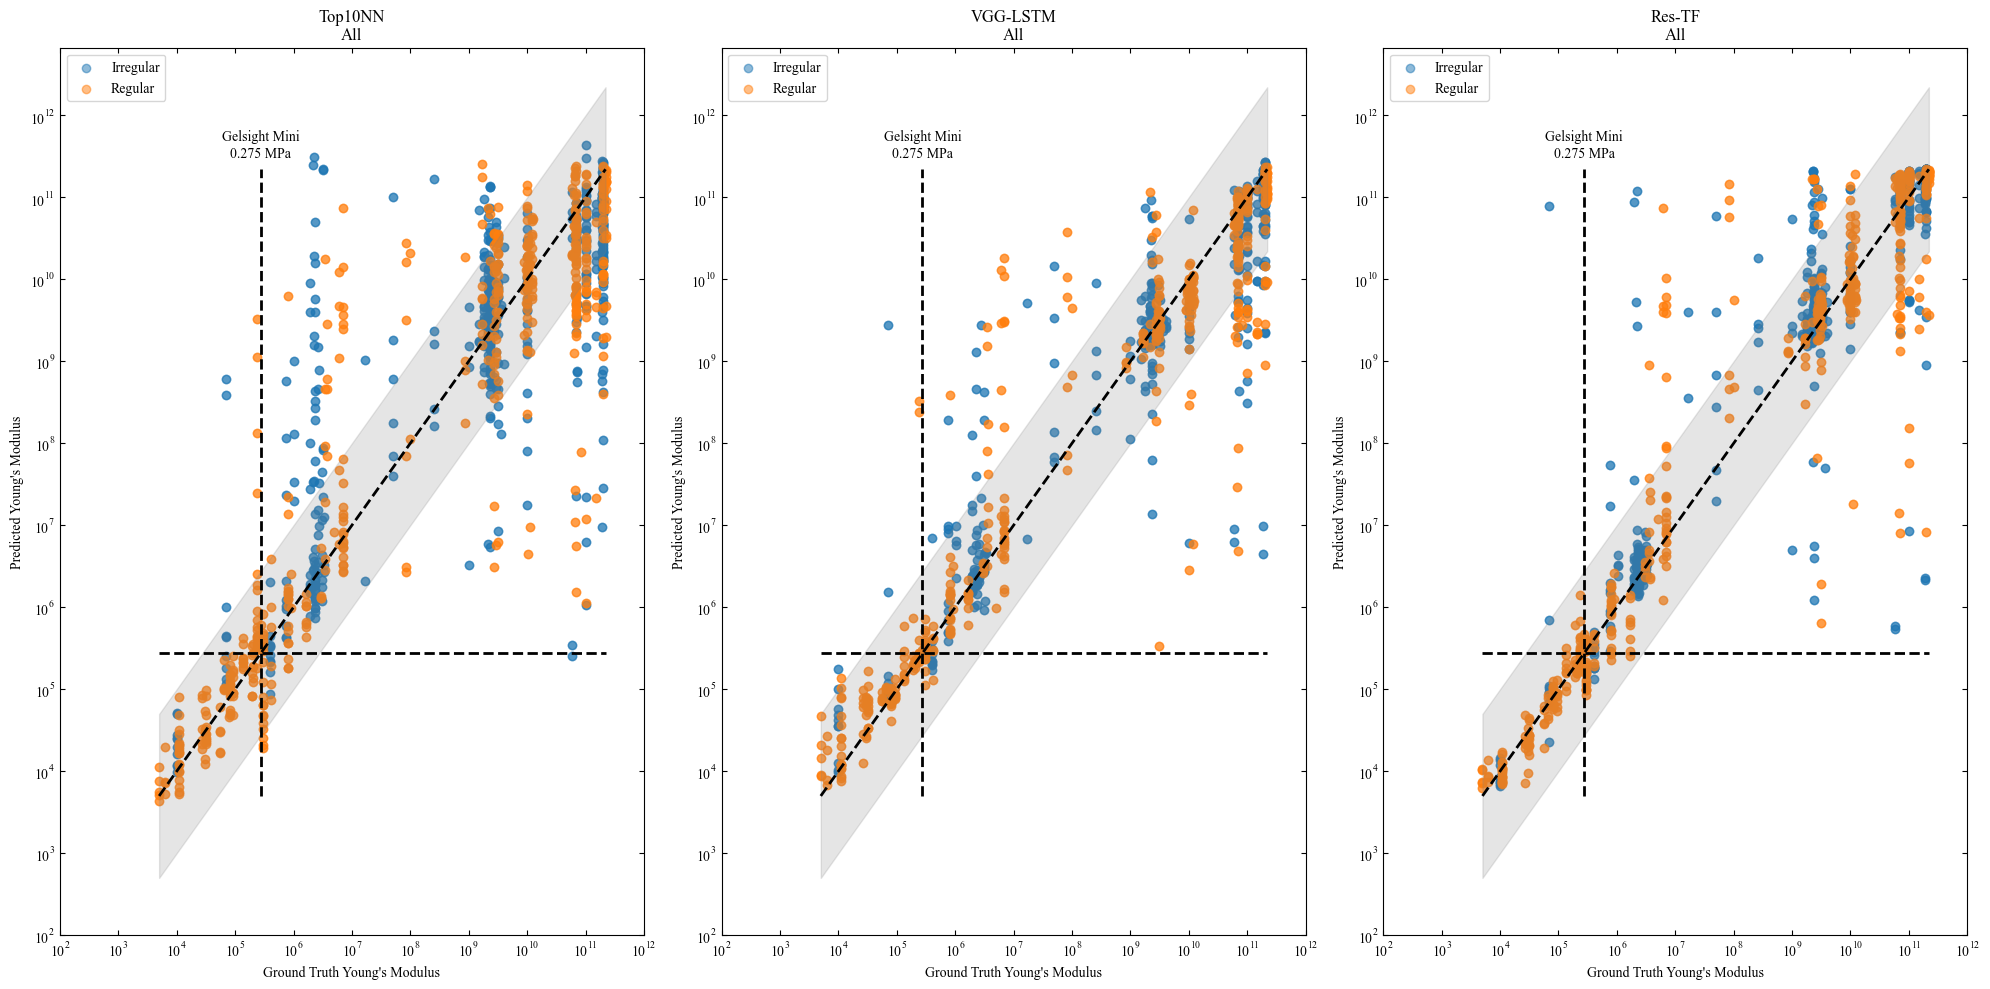

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from model.VGG_LSTM.modulus_model import ModulusModel as VGG_LSTM
from model.Res_TF.modulus_model import ModulusModel as Res_TF
from model.Top10NN.modulus_model import ModulusModel as Top10NN
from dataset.k_fold_youngs_data_module import KFoldYoungsDataModule
from collections import Counter
import torch
import numpy as np
import tqdm
import gc
plt.rcParams['font.family'] = 'Times New Roman'

model_class_dict = {
    "vgg_lstm": VGG_LSTM,
    "res_tf": Res_TF,
    "top10nn": Top10NN,
}
model_name_map = {
    "vgg": "VGG-LSTM",
    "res": "Res-TF",
    "top10nn": "Top10NN",
}
model_checkpoints = [
    Path("/home/malte.kuhlmann/youngs-modulus/data/checkpoint_unbalanced_cross_validation/top10nn/fold_0/top10nn_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random.ckpt").resolve(),
    Path("/home/malte.kuhlmann/youngs-modulus/data/checkpoint_unbalanced_cross_validation/vgg_lstm/fold_0/vgg_lstm_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random.ckpt").resolve(),
    Path("/home/malte.kuhlmann/youngs-modulus/data/checkpoint_unbalanced_cross_validation/res_tf/fold_0/res_tf_random_seen_width_transforms_log_normalize_removed_paper_random_state_42_random.ckpt").resolve(),
]

rows = 1
fig, axs = plt.subplots(len(model_checkpoints)//rows, rows, figsize=(10, 20))
axs = [axs] if len(model_checkpoints) == 1 else axs

for model_folder, ax in zip(model_checkpoints, axs):

    all_predicted = []
    all_ground_truth = []
    all_herzian = []
    
    model_name = model_folder.stem.split("_")[0]
    print(model_name)
    # fold = int(model_folder.parent.stem.split("_")[-1])
    if model_name == "top10nn":
        model = Top10NN.load_from_checkpoint(model_folder)
    elif model_name == "vgg":
        model = VGG_LSTM.load_from_checkpoint(model_folder)
    elif model_name == "res":
        model = Res_TF.load_from_checkpoint(model_folder)

    model.eval()
    model.cuda(0)
    model.hparams.use_transformations = False
    model_config = model.config
    fold = int(model_folder.parent.stem.split("_")[-1])

    data_module = KFoldYoungsDataModule(
        data_dir=model_config['data_dir'],
        training_data_folder=model_config['training_data_folder'],
        # n_frames=model_config['n_frames'],
        #img_size=model_config['img_size'],
        worker=5,
        image_style=model_config['img_style'],
        sample_type=model_config['sample_type'],
        use_estimations=model_config['use_estimations'],
        use_force=model_config['use_force'],
        use_width=model_config['use_width'],
        use_width_transforms=model_config['use_width_transforms'],
        use_markers="both",
        remove_paper=model_config['remove_paper'],
        overwrite_file=False,
        batch_size=1,
        val_on_seen_objects=model_config["val_on_seen_objects"],
        use_log_normalization=model_config['use_log_normalization'],
        exclude=model_config['exclude'],
        balance_dataset=False,
        same_test_set=False
        
    )
    data_module.make_object_attributes()
    data_module.prepare_data()
    data_module.setup(fold=fold)

    bad_objects = []
    good_objects = []
    is_irregular = []
    for batch in tqdm.tqdm(data_module.test_dataloader(apply_augmentations=False)):
        x_frames, x_forces, x_widths, x_estimations, y, object_name = batch
        outputs = model.forward(x_frames.cuda(), x_forces.cuda(), x_widths.cuda(), x_estimations.cuda(), x_frames.shape[0])
        outputs = outputs.squeeze()

        if torch.abs(torch.log10(model.unnormalization_function(outputs.cpu())) - torch.log10(model.unnormalization_function(y.cpu()))) >= 1:
            bad_objects.append(object_name)
        else:
            good_objects.append(object_name)
        
        is_irregular.append(data_module.object_to_shape[object_name[0]] == "Irregular")
        
        all_predicted.append(model.unnormalization_function(outputs.cpu()).detach().numpy())
        all_ground_truth.append(model.unnormalization_function(y.cpu()).detach().numpy())
        all_herzian.append(x_estimations.cpu().detach().numpy())
    
    all_counter.append([Counter(bad_objects), Counter(good_objects)])
    for key in all_counter[-1][0].keys():
        data_module.object_to_material[key[0]]
        print(f"{key[0]}: {all_counter[-1][0][key]}/{all_counter[-1][1][key]} {data_module.object_to_material[key[0]]} {data_module.object_to_shape[key[0]]}")

    is_irregular = np.array(is_irregular)
    all_predicted = np.array(all_predicted)
    all_ground_truth = np.array(all_ground_truth)
    all_herzian = np.concatenate(all_herzian)

    # plt.figure(figsize=(10, 10))
    ax.scatter(all_ground_truth[is_irregular], all_predicted[is_irregular], alpha=0.5, label="Irregular")
    ax.scatter(all_ground_truth[np.logical_not(is_irregular)], all_predicted[np.logical_not(is_irregular)], alpha=0.5, label="Regular")
    ax.plot([all_ground_truth.min(), all_ground_truth.max()], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)

    # Add shaded area for one order of magnitude
    ax.fill_between([all_ground_truth.min(), all_ground_truth.max()],
                    [all_ground_truth.min() * 10, all_ground_truth.max() * 10],
                    [all_ground_truth.min() / 10, all_ground_truth.max() / 10],
                    color='gray', alpha=0.2)


    ax.plot([275000, 275000], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)
    ax.plot([all_ground_truth.min(), all_ground_truth.max()], [275000, 275000], 'k--', lw=2)
    ax.text(275000, all_ground_truth.max() * 2, 'Gelsight Mini\n0.275 MPa', verticalalignment='center', horizontalalignment='center', )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Ground Truth Young\'s Modulus')
    ax.set_ylabel('Predicted Young\'s Modulus')
    ax.set_title(f"{model_name_map[model_name]}\nAll")

    # Set the same ticks for both axes
    ticks = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.legend(loc='upper left')

    # Enable ticks on all sides and point them inside
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=2)
    del data_module
    gc.collect()

fig.tight_layout()
fig.savefig("../figures/all_models_train.svg")
plt.show()

In [ ]:
for key in all_counter[-1][0].keys():
    print(key)
    data_module.object_to_material[key]
    print(f"{key}: {all_counter[-1][0][key]}/{all_counter[-1][1][key]} {data_module.object_to_material[key]} {data_module.object_to_shape[key]}")

('wooden_double_arch',)


NameError: name 'data_module' is not defined

In [ ]:
print(all_herzian[:, 1][:, 0])

In [ ]:
plt.Figure(figsize=(10, 10))
plt.scatter(all_ground_truth, all_herzian[:, 1][:, 0], alpha=0.5)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)

# Add shaded area for one order of magnitude
plt.fill_between([all_ground_truth.min(), all_ground_truth.max()],
                [all_ground_truth.min() * 10, all_ground_truth.max() * 10],
                [all_ground_truth.min() / 10, all_ground_truth.max() / 10],
                color='gray', alpha=0.2)


plt.plot([275000, 275000], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [275000, 275000], 'k--', lw=2)
plt.text(275000, all_ground_truth.max() * 2, 'Gelsight Mini\n0.275 MPa', verticalalignment='center', horizontalalignment='center', )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Ground Truth Young\'s Modulus')
plt.ylabel('Predicted Young\'s Modulus')
plt.title(f"Herzian Estimation")

# Set the same ticks for both axes
ticks = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
plt.xticks(ticks)
plt.yticks(ticks)


# Enable ticks on all sides and point them inside
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

In [ ]:
print(np.min(all_predicted))
print(np.max(all_predicted))

In [ ]:
plt.scatter(all_ground_truth, all_herzian[:, 0][:, 0], alpha=0.5)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)

# Add shaded area for one order of magnitude
plt.fill_between([all_ground_truth.min(), all_ground_truth.max()],
                [all_ground_truth.min() * 10, all_ground_truth.max() * 10],
                [all_ground_truth.min() / 10, all_ground_truth.max() / 10],
                color='gray', alpha=0.2)


plt.plot([275000, 275000], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [275000, 275000], 'k--', lw=2)
plt.text(275000, all_ground_truth.max() * 2, 'Gelsight Mini\n0.275 MPa', verticalalignment='center', horizontalalignment='center', )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Ground Truth Young\'s Modulus')
plt.ylabel('Predicted Young\'s Modulus')
plt.title(f"Elastic Estimation")

# Set the same ticks for both axes
ticks = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12]
plt.xticks(ticks)
plt.yticks(ticks + [1e13, 1e14, 1e15, 1e16])

# Enable ticks on all sides and point them inside
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Shore to Young's

In [ ]:
from dataset.k_fold_shore_data_module import KFoldShoreDataModule

data_module = KFoldShoreDataModule("../data", "hardness_ds")
data_module.prepare_data()
data_module.setup()

In [ ]:
import matplotlib.pyplot as plt
all_ground_truth = data_module.dataset["youngs"]

plt.scatter(all_ground_truth, data_module.dataset["youngs"], alpha=0.5)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)

# Add shaded area for one order of magnitude
plt.fill_between([all_ground_truth.min(), all_ground_truth.max()],
                [all_ground_truth.min() * 10, all_ground_truth.max() * 10],
                [all_ground_truth.min() / 10, all_ground_truth.max() / 10],
                color='gray', alpha=0.2)


plt.plot([275000, 275000], [all_ground_truth.min(), all_ground_truth.max()], 'k--', lw=2)
plt.plot([all_ground_truth.min(), all_ground_truth.max()], [275000, 275000], 'k--', lw=2)
plt.text(275000, all_ground_truth.max() * 2, 'Gelsight Mini\n0.275 MPa', verticalalignment='center', horizontalalignment='center', )
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Ground Truth Young\'s Modulus')
plt.ylabel('Predicted Young\'s Modulus')
plt.title(f"Elastic Estimation")

# Set the same ticks for both axes
ticks = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7]#, 1e8, 1e9, 1e10, 1e11, 1e12]
plt.xticks(ticks)
plt.yticks(ticks + [1e13, 1e14, 1e15, 1e16])

# Enable ticks on all sides and point them inside
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)